# GoTriple metadata cleaning — strategies, queries and timings

Two problems, two sections:

- **[1. Authors](#1-authors)** — recovering broken names, and deciding which profiles are the same person
- **[2. Licenses](#2-licenses)** — recovering a usable license for documents that have none
- **[2.4 Empty DOI](#24-empty-doi)** — backfill `doi` when the field is an empty string

Every subsection shows the same three things:

1. **the schema** — what the strategy tries, in order, and where it gives up
2. **the Elasticsearch query actually executed** — captured from `es_helpers.QUERY_LOG`, never retyped
3. **a live run**, timed

Everything runs against `triple-profiles-prod` / `triple-documents-prod` through
Elasticsearch. Credentials come from `.env`; see `src/es_helpers.py`.

> The three constants in the next cell drive everything. Samples are small so the
> notebook finishes in minutes; raise them to scale —
> cost is linear in the number of records, except where noted in §3.


In [61]:
import ast
import contextlib, io, json, re, time
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

from src.es_helpers import last_query
from src import pipelines
from src.functions_license import build_license_query, count_elastic_documents
from src.functions_doi import build_doi_query, count_elastic_doi_documents
from src.functions_name import count_elastic_authors, NAME_FILTER_QUERIES

# ============================================================================
# INITIAL PARAMETERS - change these, re-run, everything below follows
# ============================================================================
AUTHOR_NAME     = "Wang, Y."   # the name searched in the disambiguation subsection (1.4)
AUTHOR_SAMPLE   = 500          # author profiles to pull per subsection  (1.1 - 1.4)
DOCUMENT_SAMPLE = 500         # documents to pull for license recovery  (2.3)
DOI_SAMPLE      = 500         # §2.4: same size as AUTHOR_SAMPLE / DOCUMENT_SAMPLE
# ============================================================================

TIMINGS = {}
plt.rcParams.update({"figure.figsize": (9, 4.5), "axes.spines.top": False,
                     "axes.spines.right": False, "axes.grid": True, "grid.alpha": .3})
OK, BAD, ALT = "#4c72b0", "#c44e52", "#55a868"


@contextlib.contextmanager
def timed(label):
    """Record wall-clock time so §3 is measured, not guessed."""
    start = time.perf_counter()
    yield
    TIMINGS[label] = time.perf_counter() - start
    print(f"[{label}] {TIMINGS[label]:.1f}s")


def quietly(function, *args, **kwargs):
    """Run a pipeline stage, capturing its per-record chatter."""
    buffer = io.StringIO()
    with contextlib.redirect_stdout(buffer):
        result = function(*args, **kwargs)
    return result, buffer.getvalue()


def digest(output, keep=("->", "*", "---")):
    """Print only the summary lines from captured pipeline output."""
    for line in output.splitlines():
        if line.strip().startswith(keep):
            print(line)


def params(**values):
    """Print the parameters a run was given, so every result is self-describing."""
    width = max(len(k) for k in values)
    print("parameters")
    for key, value in values.items():
        print(f"  {key.replace('_', ' '):<{width}} : {value}")
    print()


def show_query(index_contains, title="query executed"):
    entry = last_query(index_contains)
    print(f"{title} — index: {entry['index']}")
    print(json.dumps(entry["body"], indent=2, ensure_ascii=False))


def show_markdown(text):
    """Render a table built from the numbers this run produced. Nothing quoted in
    the prose below is typed in, so it cannot disagree with the cell above it."""
    display(Markdown(text))


def stage_outcomes(rows, title, note=None):
    """The bar chart every stage ends with: one bar per outcome, in the order
    (solved, settled, open). Each bar carries its own count and share, so the
    colour only reinforces the label rather than carrying it."""
    palette = {"solved": ALT, "settled": OK, "open": BAD}
    total = sum(int(row[1]) for row in rows) or 1
    rows = [row for row in rows if int(row[1])] or rows   # an empty outcome is not a bar
    labels = [row[0] for row in rows]
    values = [int(row[1]) for row in rows]

    fig, ax = plt.subplots(figsize=(9, .5 * len(rows) + 1.3))
    ax.barh(labels[::-1], values[::-1], height=.55,
            color=[palette[row[2]] for row in rows][::-1])
    for position, value in enumerate(values[::-1]):
        ax.text(value + total * .012, position, f"{value:,}   {value / total:.0%}",
                va="center", color="#52514e")

    ax.set_xlim(0, total * 1.2)
    ax.set_xticks([])
    ax.grid(False)
    ax.set_title(title, loc="left", fontweight="bold", pad=20 if note else 10)
    if note:
        ax.text(0, 1.03, note, transform=ax.transAxes, color="#8a8a8a", fontsize=9, va="bottom")
    plt.tight_layout(); plt.show()


def as_list(value):
    """A cell that holds a stringified list, read back safely. Excel truncates a
    cell at 32,767 characters, so the longest lists come back cut off mid-item
    and will not parse as Python - hence the regex fallback. Quoted text with an
    apostrophe in it ("People's Republic") is why the regex is not the first
    choice."""
    if not isinstance(value, str) or not value.strip():
        return []
    try:
        parsed = ast.literal_eval(value)
    except (ValueError, SyntaxError):
        return re.findall(r"'([^']*)'", value)
    return list(parsed) if isinstance(parsed, (list, tuple, set)) else [parsed]


---
# 1. Authors

`triple-profiles-prod` holds the author profiles. Two unrelated problems live here.

**A name can be broken in several distinct ways**, and they do not respond to the
same treatment at all:

In [62]:
# Counted from the index rather than typed in, so the table cannot drift from it.
NAME_PROBLEMS = [("1.1", "an ORCID sits inside the name",   "orcid", "almost all recoverable"),
                 ("1.2", "the name is empty",               "empty", "rarely recoverable"),
                 ("1.3", "the name is a URL or bare digits", "junk", "URLs no; bare numbers are repository ids")]

populations = {key: count_elastic_authors(name_filter=key) for _, _, key, _ in NAME_PROBLEMS}

show_markdown(
    f"`triple-profiles-prod` holds **{count_elastic_authors():,} author profiles**. Each subsection "
    f"below pulls `AUTHOR_SAMPLE` = **{AUTHOR_SAMPLE}** of the profiles it selects.\n\n"
    "| §  | problem | profiles | this run | outlook |\n"
    "|----|---------|---------:|---------:|---------|\n"
    + "".join(f"| {section} | {problem} | {populations[key]:,} | "
             f"{min(AUTHOR_SAMPLE, populations[key]):,} | {outlook} |\n"
             for section, problem, key, outlook in NAME_PROBLEMS))

`triple-profiles-prod` holds **23,832,229 author profiles**. Each subsection below pulls `AUTHOR_SAMPLE` = **500** of the profiles it selects.

| §  | problem | profiles | this run | outlook |
|----|---------|---------:|---------:|---------|
| 1.1 | an ORCID sits inside the name | 2,871 | 500 | almost all recoverable |
| 1.2 | the name is empty | 2,039 | 500 | rarely recoverable |
| 1.3 | the name is a URL or bare digits | 1,832 | 500 | URLs no; bare numbers are repository ids |


**Separately**, many profiles that *have* a fine name are duplicates of each
other (§1.4). That is a different question — not *what is this person called*
but *are these records the same person* — and it is solved by clustering, not
by lookups.

## 1.1 Names with an ORCID inside

The highest-yield repair in the project. The field holds the identifier, alone
or stuck onto a real name:

```
 '0000-0002-1588-0683'
 'Ana Morales, 0000-0001-6969-2883'
 'https://orcid.org/0000-0003-4140-8101'
 'Ardeshir Bazrkar orcid'                 ← the word survived, the id did not
```

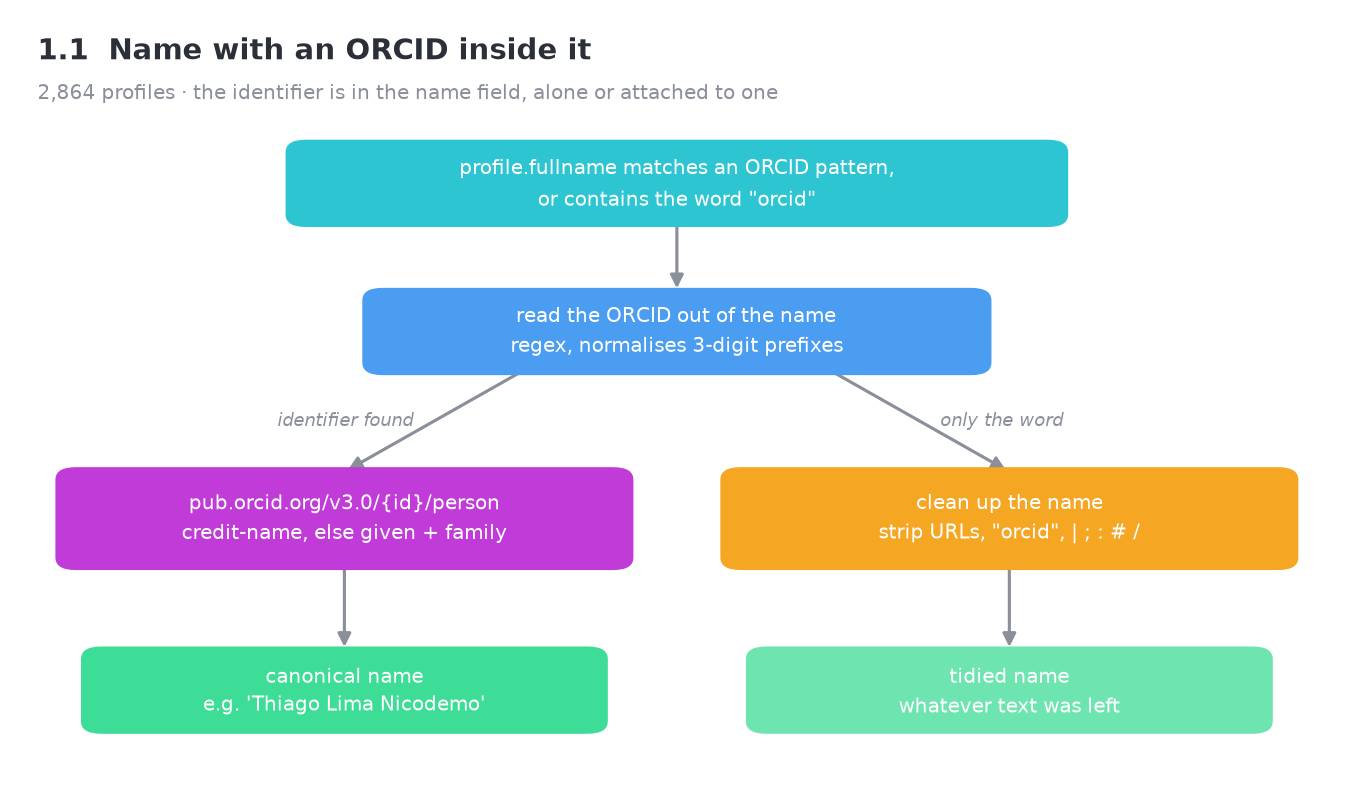

**Checking the documents index first would be wasted work.** The document holds
the *identical* broken string — GoTriple copies the name from it:

```
profile : 'Ana Morales, 0000-0001-6969-2883'
document: ['Ana Morales, 0000-0001-6969-2883']
```

ORCID is the only source that actually knows the person's name, so the pipeline
goes straight there whenever an identifier is present.

In [63]:
print(f"profiles with an ORCID in the name: {count_elastic_authors(name_filter='orcid'):,}")
print(json.dumps(NAME_FILTER_QUERIES["orcid"], indent=2))

profiles with an ORCID in the name: 2,871
{
  "bool": {
    "should": [
      {
        "regexp": {
          "fullname.keyword": ".*[0-9]{4}-[0-9]{4}-[0-9]{4}-[0-9X]{4}.*"
        }
      },
      {
        "match": {
          "fullname": "orcid"
        }
      }
    ],
    "minimum_should_match": 1
  }
}


In [64]:
params(task="orcid_names", index="triple-profiles-prod", source="elastic",
       selection="fullname matches an ORCID pattern, or contains 'orcid'",
       records_requested=AUTHOR_SAMPLE, population=f"{count_elastic_authors(name_filter='orcid'):,}")

with timed("1.1 names: orcid inside"):
    _, output = quietly(pipelines.run_author_pipeline,
                        api_params={"size": str(AUTHOR_SAMPLE)}, source="elastic", task="orcid_names")

show_query("profiles", "\nselection query")
print()
digest(output)

parameters
  task              : orcid_names
  index             : triple-profiles-prod
  source            : elastic
  selection         : fullname matches an ORCID pattern, or contains 'orcid'
  records requested : 500
  population        : 2,871

[1.1 names: orcid inside] 60.8s

selection query — index: triple-profiles-prod
{
  "size": 100,
  "query": {
    "bool": {
      "should": [
        {
          "regexp": {
            "fullname.keyword": ".*[0-9]{4}-[0-9]{4}-[0-9]{4}-[0-9X]{4}.*"
          }
        },
        {
          "match": {
            "fullname": "orcid"
          }
        }
      ],
      "minimum_should_match": 1
    }
  },
  "sort": [
    {
      "id": "asc"
    }
  ],
  "search_after": [
    "andrea_orcid_caracausi_IsDXSD_GHaTbSP7t3IjiT"
  ]
}

--- STARTING AUTHOR NAME PIPELINE ---
-> what is wrong with them: {'orcid embedded in name': 303, 'orcid only': 195, 'stray orcid word': 2}
--- Name recovery by problem ---
     * orcid embedded in name    303/303  re

In [65]:
orcid_names = pd.read_excel("data/output/authors_orcid_names_elastic.xlsx")
print(orcid_names[["fullname", "fullname_fix", "name_source"]].head(8).to_string(index=False))

                                                                                                   fullname                                                                                           fullname_fix      name_source
                                                                        Andrea Demaria, 0000-0002-5450-0444                                                                                      Andrea L. Demaria        orcid api
                                                                           Ana Morales, 0000-0001-6969-2883                                                                                            Ana Morales        orcid api
                                                                          Anne Lutomia, 0000-0001-6029-8783                                                                                   Anne Namatsi Lutomia        orcid api
                                                                                        

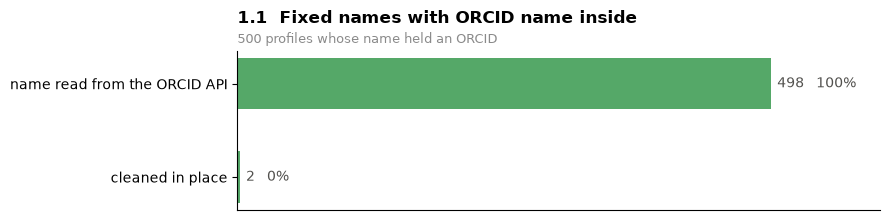

In [66]:
sources = pd.read_excel("data/output/authors_orcid_names_elastic.xlsx")["name_source"].value_counts()
stage_outcomes([
    ("name read from the ORCID API", sources.get("orcid api", 0), "solved"),
    ("cleaned in place", sources.get("cleaned in place", 0), "solved"),
    ("still broken", sources.get("not recovered", 0), "open"),
], "1.1  Fixed names with ORCID name inside", f"{sources.sum():,} profiles whose name held an ORCID")

## 1.2 Empty names

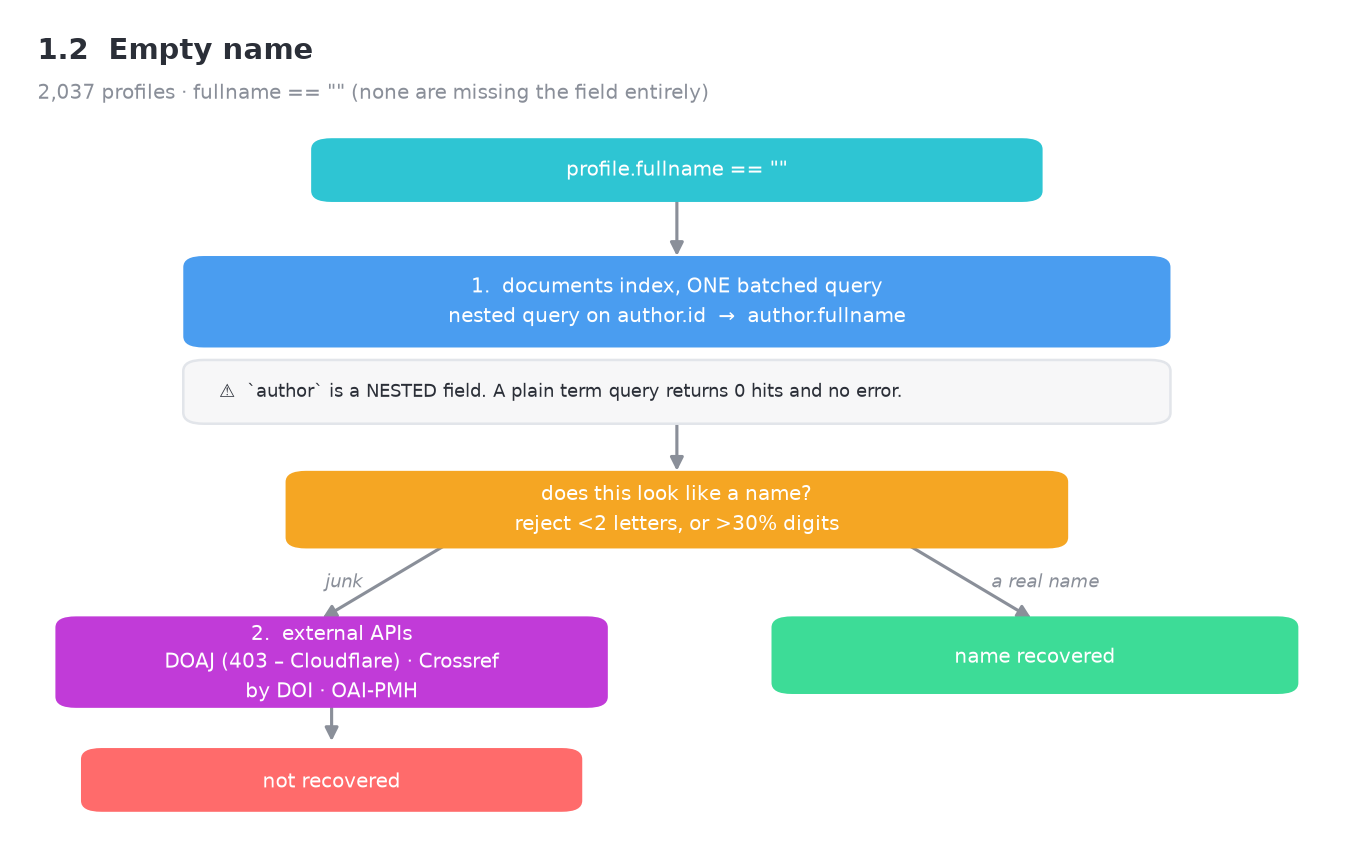

**Expect this to fail, and that is the finding.** Measured yield over 300 blank
profiles: **13 (4.3%)** — and most of those are not people:
`(Eds)`, `(sous la dir. de)`, `(pdf Formatında)`, `Author`.

These names are empty *because the source metadata was junk*. GoTriple blanked
them deliberately, and the document they came from still holds that same junk.

In [67]:
print(f"profiles with an empty name: {count_elastic_authors(name_filter='empty'):,}")
print(json.dumps(NAME_FILTER_QUERIES["empty"], indent=2))

profiles with an empty name: 2,039
{
  "term": {
    "fullname.keyword": ""
  }
}


In [68]:
params(task="empty_names", index="triple-profiles-prod", source="elastic",
       selection='fullname.keyword == ""',
       records_requested=AUTHOR_SAMPLE, population=f"{count_elastic_authors(name_filter='empty'):,}")

with timed("1.2 names: empty"):
    _, output = quietly(pipelines.run_author_pipeline,
                        api_params={"size": str(AUTHOR_SAMPLE)}, source="elastic", task="empty_names")

show_query("profiles", "\nselection query")
print()
digest(output)

parameters
  task              : empty_names
  index             : triple-profiles-prod
  source            : elastic
  selection         : fullname.keyword == ""
  records requested : 500
  population        : 2,039

[1.2 names: empty] 260.9s

selection query — index: triple-profiles-prod
{
  "size": 100,
  "query": {
    "term": {
      "fullname.keyword": ""
    }
  },
  "sort": [
    {
      "id": "asc"
    }
  ],
  "search_after": [
    "editoria_rbpec_RIgmYILXP_cdkqPq-Mb9F"
  ]
}

--- STARTING AUTHOR NAME PIPELINE ---
-> what is wrong with them: {'empty': 500}
-> 28/500 recovered from the documents index
--- Name recovery by problem ---
     * empty                      28/500  recovered
-> Author data saved to '/Users/paulopiimenta/projects/lumen/lumen-metadata-t43/data/output/authors_empty_names_elastic.xlsx'
-> Candidates sharing an ORCID : 0 records (across 0 unique ORCIDs)
-> Candidates sharing a resolved Name : 2 records (across 1 unique clusters)
     * Master Name: Editor

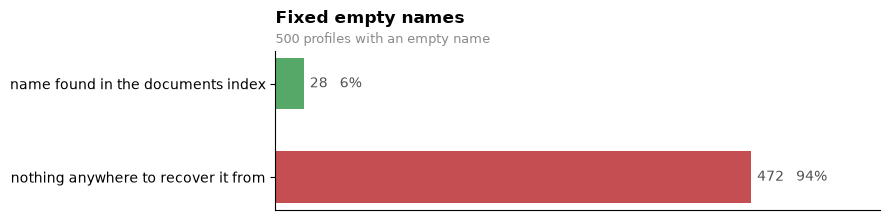

In [69]:
sources = pd.read_excel("data/output/authors_empty_names_elastic.xlsx")["name_source"].value_counts()
stage_outcomes([
    ("name found in the documents index", sources.get("documents index", 0), "solved"),
    ("nothing anywhere to recover it from", sources.get("not recovered", 0), "open"),
], "Fixed empty names", f"{sources.sum():,} profiles with an empty name")

## 1.3 URL or bare-digit names

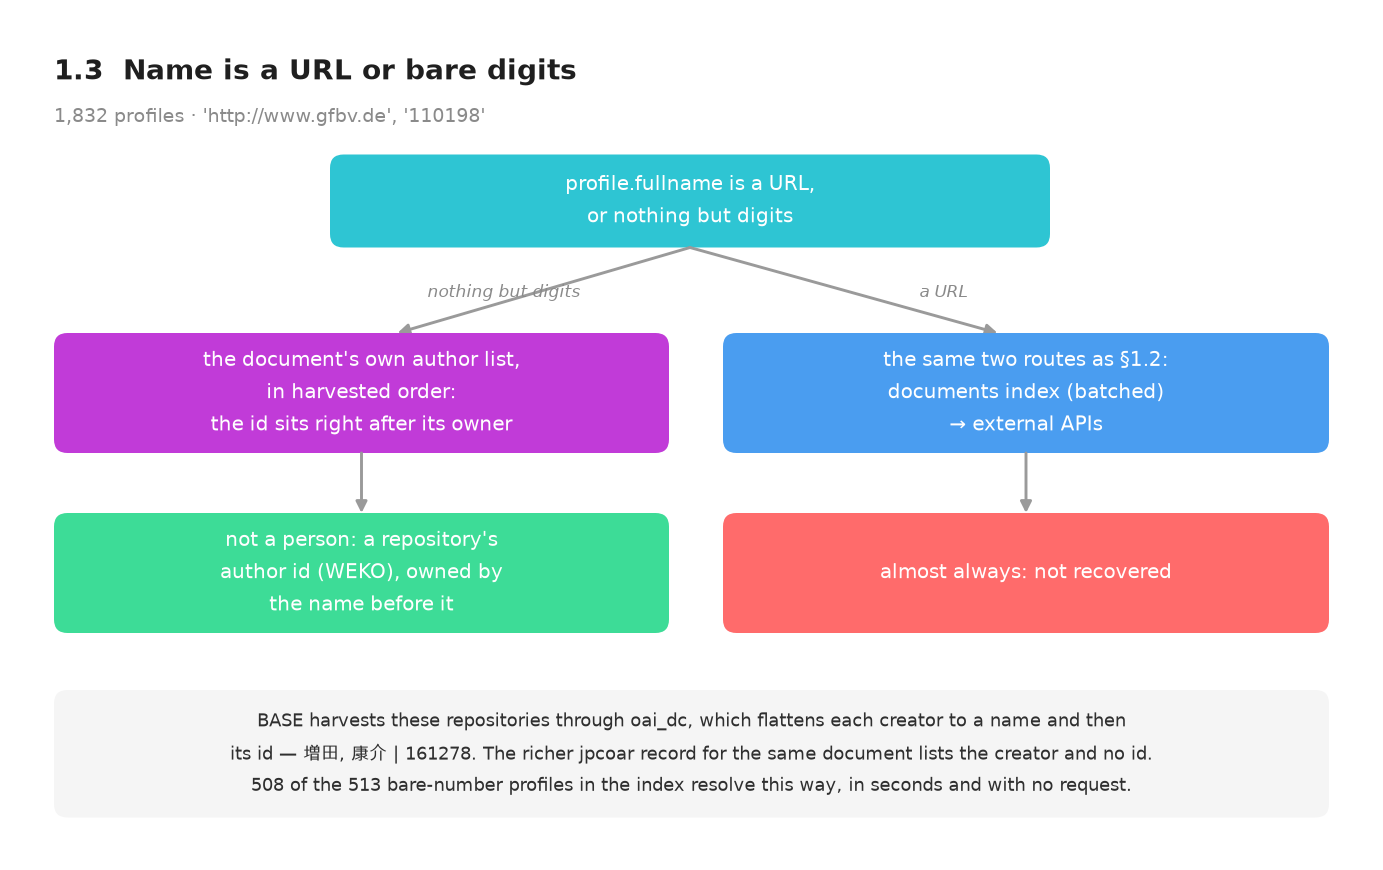

A URL is not a person — and neither is a bare number, but for a different reason.
**Every bare-number name in the index is a repository's own author id.** WEKO
repositories (u-tokyo, niigata) publish that id as a second `dc:creator`, right
after the creator it belongs to; BASE harvests the flattened `oai_dc` view, so
GoTriple mints a profile for it:

```
jpcoar   creatorName: 増田, 康介                     ← one creator
oai_dc   dc:creator : 増田, 康介 | 161278            ← name, then her id
```

There is no name to recover for these, so the pipeline stops asking. The pairing
survives into the documents index, where `author` keeps the harvested order, and
`resolve_repository_ids()` reads the owner off the entry before the id — no
request to anyone. They are reported as **repository id**, with the owner in
`belongs_to`, and never counted as a recovered name.

The URLs are the genuine remainder: they take the same two routes as §1.2 and
almost always come back empty.

In [70]:
print(f"URL / numeric names: {count_elastic_authors(name_filter='junk'):,}")
print(json.dumps(NAME_FILTER_QUERIES["junk"], indent=2))

params(task="junk_names", index="triple-profiles-prod", source="elastic",
       selection="fullname is a URL or bare digits",
       records_requested=AUTHOR_SAMPLE, population=f"{count_elastic_authors(name_filter='junk'):,}")

with timed("1.3 names: url / numeric"):
    _, output = quietly(pipelines.run_author_pipeline,
                        api_params={"size": str(AUTHOR_SAMPLE)}, source="elastic", task="junk_names")
print()
digest(output)

URL / numeric names: 1,832
{
  "bool": {
    "should": [
      {
        "match": {
          "fullname": "http"
        }
      },
      {
        "regexp": {
          "fullname.keyword": "[0-9]+"
        }
      }
    ],
    "minimum_should_match": 1
  }
}
parameters
  task              : junk_names
  index             : triple-profiles-prod
  source            : elastic
  selection         : fullname is a URL or bare digits
  records requested : 500
  population        : 1,832

[1.3 names: url / numeric] 171.9s

--- STARTING AUTHOR NAME PIPELINE ---
-> what is wrong with them: {'numeric': 500}
-> 216/500 numeric names are a repository's own author id, not a person
-> 0/284 recovered from the documents index
--- Name recovery by problem ---
     * numeric                     0/500  recovered  (216 are repository ids, not people)
-> Author data saved to '/Users/paulopiimenta/projects/lumen/lumen-metadata-t43/data/output/authors_junk_names_elastic.xlsx'
-> Candidates sharing an ORCID 

In [71]:
import re

from src.functions_name import resolve_repository_ids
from src.es_helpers import es_search, DOCUMENTS_INDEX

junk = pd.read_excel("data/output/authors_junk_names_elastic.xlsx")
digits = junk[junk["fullname"].astype(str).str.fullmatch(r"\d+")].copy()
digits["author_of"] = digits["author_of"].map(
    lambda value: re.findall(r"'([^']*)'", value) if isinstance(value, str) else [])

with timed("1.3 repository ids"):
    owners = resolve_repository_ids(digits.to_dict("records"))

# the mechanism, on one document: the id sits directly after the name it belongs to
example = digits.iloc[0]
document = es_search({"size": 1, "query": {"term": {"id": example["author_of"][0]}},
                      "_source": ["id", "author"]}, index=DOCUMENTS_INDEX)["hits"]["hits"][0]

show_markdown(
    f"**{len(owners)} of {len(digits)} bare-number profiles are a repository id**, "
    f"resolved from the documents index alone — no ORCID call, no scraping.\n\n"
    f"`{document['_source']['id']}` stores its authors in the order they were harvested:\n\n"
    + "".join(f"- {'**' + str(a['fullname']) + '**  ← the id' if str(a['fullname']).isdigit() else a['fullname']}\n"
             for a in document["_source"]["author"])
    + "\n| bare number | belongs to |\n|---|---|\n"
    + "".join(f"| `{row['fullname']}` | {owners.get(str(row['id']), '—')} |\n"
             for _, row in digits.head(5).iterrows()))

[1.3 repository ids] 2.9s


**495 of 500 bare-number profiles are a repository id**, resolved from the documents index alone — no ORCID call, no scraping.

`ftniigatauniv:oai:niigata-u.repo.nii.ac.jp:00004456` stores its authors in the order they were harvested:

- 蘆田, 一郎
- **48473**  ← the id

| bare number | belongs to |
|---|---|
| `48473` | 蘆田, 一郎 |
| `69763` | ハスバガン |
| `107580` | 久本, 貴志 |
| `156157` | 下保, 敏和 |
| `161278` | 増田, 康介 |


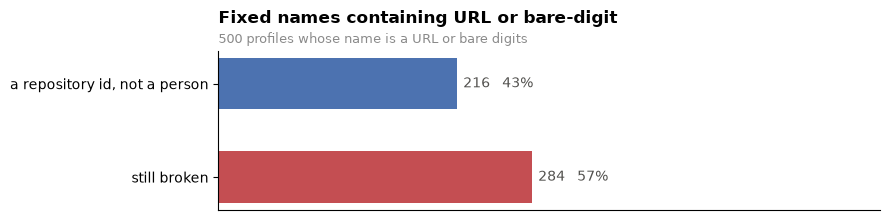

In [72]:
sources = pd.read_excel("data/output/authors_junk_names_elastic.xlsx")["name_source"].value_counts()
recovered = sum(sources.get(key, 0) for key in ("documents index", "orcid api", "cleaned in place"))
stage_outcomes([
    ("name recovered", recovered, "solved"),
    ("a repository id, not a person", sources.get("repository id", 0), "settled"),
    ("already a usable name", sources.get("unchanged", 0), "settled"),
    ("still broken", sources.get("not recovered", 0), "open"),
], "Fixed names containing URL or bare-digit", f"{sources.sum():,} profiles whose name is a URL or bare digits")

## 1.4 Disambiguation

Not *what is this person called* but *are these records the same person*. Split
into three phases so the last one is deterministic.

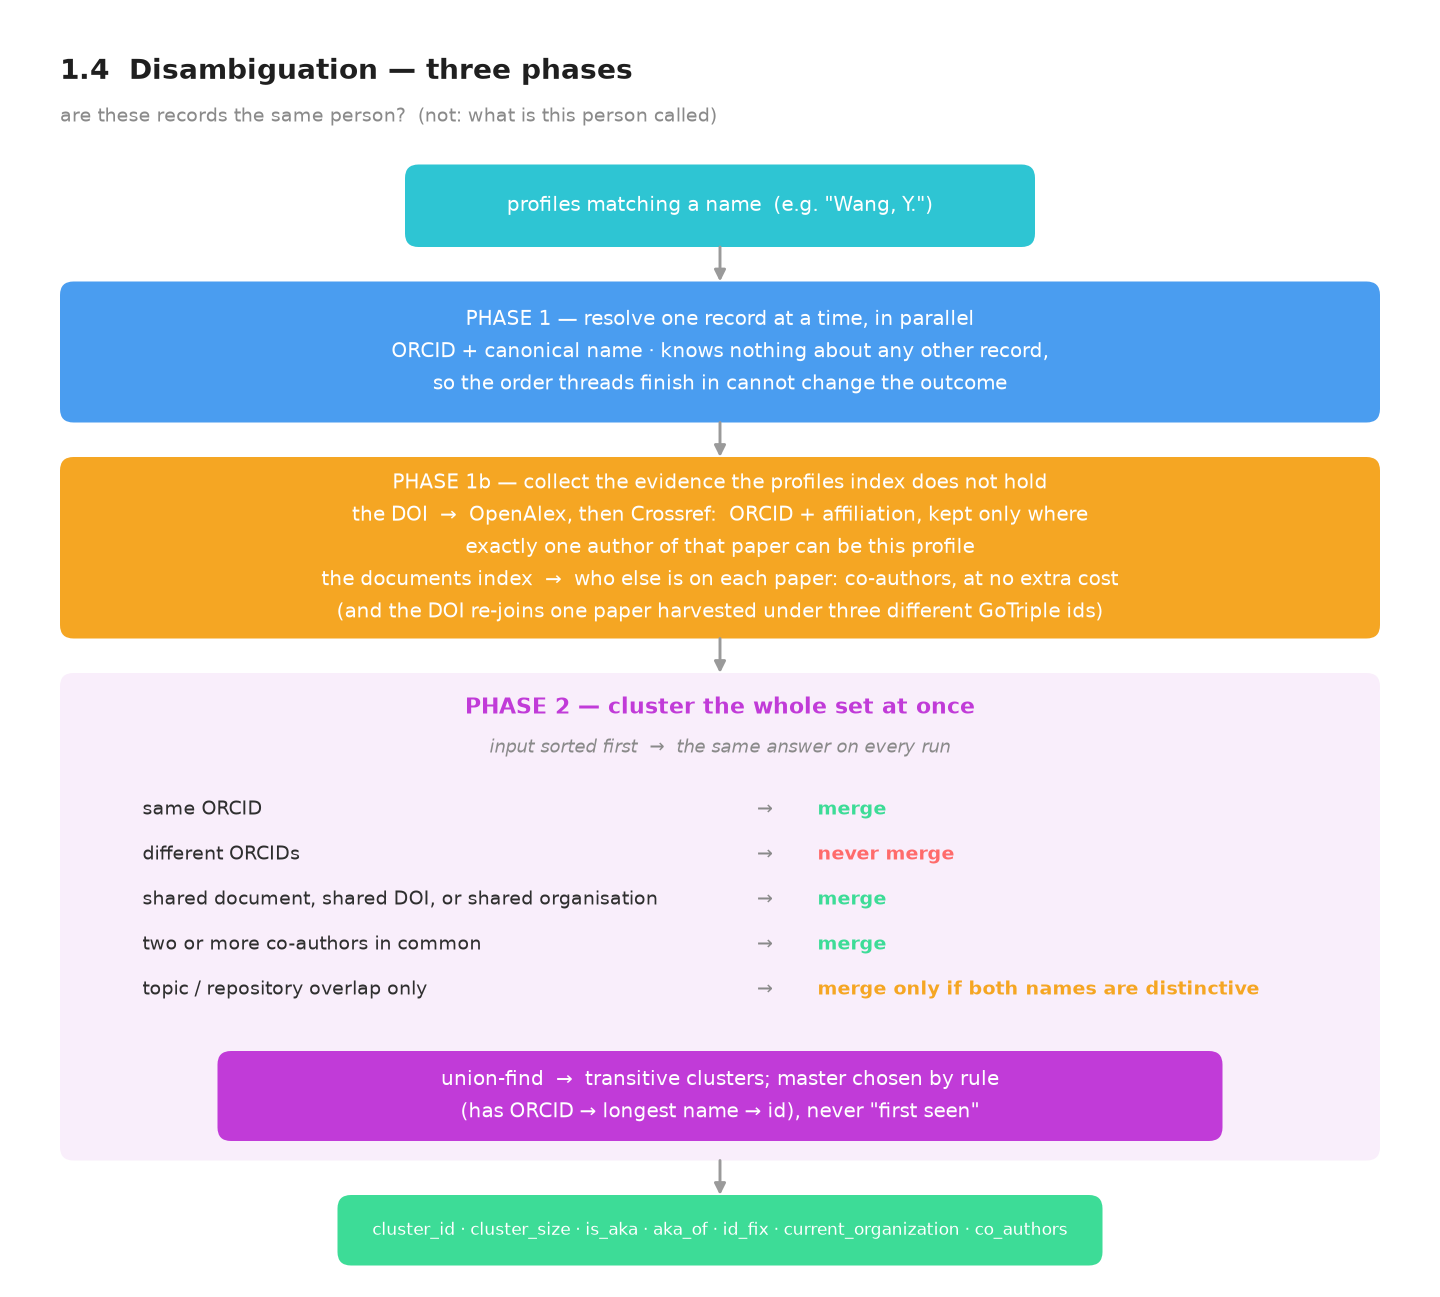

**The evidence has to come from the papers.** `triple-profiles-prod` carries no
ORCID and no `current_organization`, so on the index alone a set of `Wang, Y.`
profiles offers nothing but a name and a coarse topic — and a name shared by
2,500 profiles is not evidence of anything. Phase 1b therefore collects what the
index does not hold:

| from | evidence | cost |
|---|---|---|
| the DOI, through OpenAlex then Crossref | ORCID, affiliation | one lookup per *distinct* DOI, cached |
| the documents index | the other authors on each paper | none — it is already there |
| the DOI again | the document's real identity across repositories | none |

**Co-authors are the strongest signal available here.** Two people who happen to
share a name do not share a circle of collaborators; the same person usually
does. A paper on flight delays during solar flares and one on space weather and
flight delays, harvested under different ids and carrying different DOIs, share
fourteen co-authors — the same person. A QSAR paper on soil sorption
coefficients shares none of them with either, and its `Wang, Y.` turns out to be
Ya-nan Wang. The rule asks for **two** shared co-authors, not one, and papers
with more than 25 authors are excluded from it entirely: inside an
800-author collaboration everybody shares everybody, so co-authorship there says
nothing about who anyone is.

ORCIDs from a DOI are only kept where **exactly one author of that paper can be
this profile** — these papers routinely carry several Wangs, and picking one of
them would invent evidence rather than find it.

In [ ]:
print(f"profiles matching {AUTHOR_NAME!r}: {count_elastic_authors(query=AUTHOR_NAME):,}")

params(task="disambiguate", strategy="cluster", index="triple-profiles-prod", source="elastic",
       name_searched=AUTHOR_NAME, records_requested=AUTHOR_SAMPLE,
       population=f"{count_elastic_authors(query=AUTHOR_NAME):,}")

with timed("1.4 disambiguation: cluster"):
    _, output = quietly(pipelines.run_author_pipeline,
                        api_params={"size": str(AUTHOR_SAMPLE), "q": AUTHOR_NAME},
                        source="elastic", task="disambiguate", strategy="cluster")

show_query("profiles", "\nselection query")
print()
digest(output)

profiles matching 'Wang, Y.': 2,554
parameters
  task              : disambiguate
  strategy          : cluster
  index             : triple-profiles-prod
  source            : elastic
  name searched     : Wang, Y.
  records requested : 500
  population        : 2,554



In [ ]:
import collections

identities = pd.read_excel("data/output/authors_disambiguation_cluster_elastic.xlsx")
with_orcid = int(identities["id_fix"].notna().sum()) if "id_fix" in identities else 0
organizations = identities["current_organization"].map(as_list) if "current_organization" in identities else []
with_org = sum(1 for orgs in organizations if orgs)
dois = {doi for value in identities.get("doi", []) for doi in as_list(value)}

show_markdown(
    f"""### What the DOIs contributed

| evidence | before the DOI pass | after |
|---|---:|---:|
| profiles carrying an ORCID | 0 | {with_orcid} of {len(identities)} |
| profiles carrying an organisation | 0 | {with_org} of {len(identities)} |
| distinct works behind them | — | {len(dois)} DOIs |

Both columns start at zero because the profiles index holds neither field for
these people. Every value on the right came from the papers themselves.""")

if with_org:
    counted = collections.Counter(org for orgs in organizations for org in orgs)
    print("most frequent affiliations found:")
    for organization, count in counted.most_common(6):
        print(f"   {count:>3}  {organization[:70]}")

### What the DOIs contributed

| evidence | before the DOI pass | after |
|---|---:|---:|
| profiles carrying an ORCID | 0 | 28 of 100 |
| profiles carrying an organisation | 0 | 48 of 100 |
| distinct works behind them | — | 83 DOIs |

Both columns start at zero because the profiles index holds neither field for
these people. Every value on the right came from the papers themselves.

most frequent affiliations found:
     7  University of Virginia
     4  Wayne State University
     3  Central China Normal University
     3  University of Geneva
     2  Tsinghua University
     2  California Institute of Technology


In [ ]:
import itertools

from src.es_helpers import es_search, DOCUMENTS_INDEX

identities = pd.read_excel("data/output/authors_disambiguation_cluster_elastic.xlsx")
for column in ("co_authors", "author_of", "doi"):
    if column in identities:
        identities[column] = identities[column].map(as_list)


def describe(document_id):
    """Title and year, so a pair can be read rather than just counted."""
    hits = es_search({"size": 1, "query": {"term": {"id": document_id}},
                      "_source": ["headline", "date_published"]},
                     index=DOCUMENTS_INDEX)["hits"]["hits"]
    if not hits:
        return document_id[:60], "?"
    source = hits[0]["_source"]
    title = ((source.get("headline") or [{}])[0].get("text") or document_id).split(" ; ")[0]
    return title[:72], str(source.get("date_published") or "?")[:4]


# a pair that merged on co-authors alone - no shared document id, no shared DOI
merged_pair = None
for _, group in identities[identities["cluster_size"] > 1].groupby("cluster_id"):
    rows = group.to_dict("records")
    for left, right in itertools.combinations(rows, 2):
        shared = set(left["co_authors"]) & set(right["co_authors"])
        if (len(shared) >= 2 and not set(left["doi"]) & set(right["doi"])
                and not set(left["author_of"]) & set(right["author_of"])):
            merged_pair = (left, right, shared)
            break
    if merged_pair:
        break

# and a pair the same name did *not* join
alone = [row for row in identities[identities["cluster_size"] == 1].to_dict("records") if row["co_authors"]]
apart_pair = next(((left, right) for left, right in itertools.combinations(alone[:25], 2)
                   if not set(left["co_authors"]) & set(right["co_authors"])), None)

lines = ["### Two records that are one person, and two that are not", ""]

if merged_pair:
    left, right, shared = merged_pair
    lines.append(f"**Merged** — {len(shared)} co-authors in common, no shared document id and no shared DOI:\n")
    for row in (left, right):
        title, year = describe(row["author_of"][0]) if row["author_of"] else ("(no document)", "?")
        lines.append(f"- `{row['id']}` · {year} · {title}")
    lines.append(f"\n  shared co-authors: {' · '.join(sorted(shared)[:8])}"
                 + (" …" if len(shared) > 8 else ""))
    lines.append("\n  → *two or more co-authors in common* fires. Neither the document id nor the "
                 "DOI would have joined these two.\n")
else:
    lines.append("_No pair in this sample merged on co-authors alone._\n")

if apart_pair:
    left, right = apart_pair
    lines.append("**Kept apart** — the same name, and nothing else in common:\n")
    for row in (left, right):
        title, year = describe(row["author_of"][0]) if row["author_of"] else ("(no document)", "?")
        lines.append(f"- `{row['id']}` · {year} · {title}")
    lines.append(f"\n  shared co-authors: none  ·  "
                 f"{len(left['co_authors'])} and {len(right['co_authors'])} respectively")
    lines.append("\n  → no rule fires. A shared surname and initial is not evidence, so they stay apart.")

show_markdown("\n".join(lines))

### Two records that are one person, and two that are not

**Merged** — 5 co-authors in common, no shared document id and no shared DOI:

- `wang_y_0zSWdFwA02iO10F1JcVrK` · 2005 · Specific heat, magnetic susceptibility, resistivity and thermal expansio
- `wang_y_1kLMWg3X0ufiTPAmkTf6u` · 2006 · Superconductivity mediated by a soft phonon mode: Specific heat, resisti

  shared co-authors: abe|s · junod|a · lortz|r · meingast|c · paderno|y

  → *two or more co-authors in common* fires. Neither the document id nor the DOI would have joined these two.

**Kept apart** — the same name, and nothing else in common:

- `wang_y_3vEhz_GMMkirtTXC7_E1G` · 2022 · Challenges and responses: A Complex Dynamic Systems approach to explorin
- `y_y_wang_CaPIAS20yMG27Y6_q-usc` · 2021 · The prevalence of psychiatric comorbidities during the SARS and COVID-19

  shared co-authors: none  ·  21 and 9 respectively

  → no rule fires. A shared surname and initial is not evidence, so they stay apart.

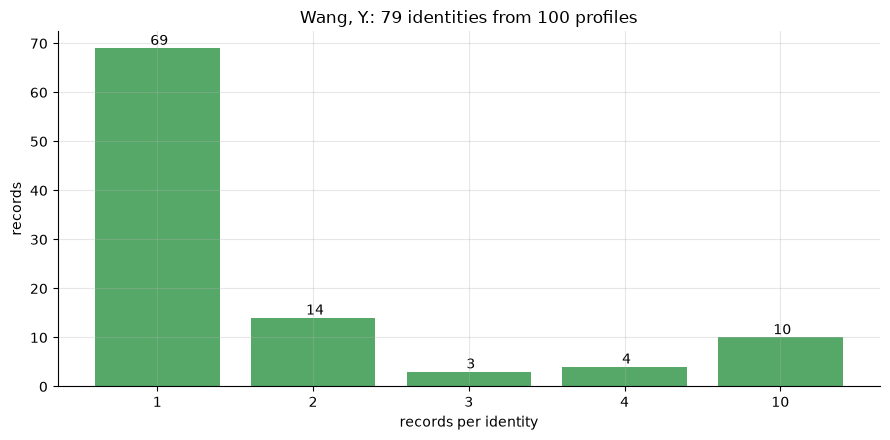

In [ ]:
clustered = pd.read_excel("data/output/authors_disambiguation_cluster_elastic.xlsx")
sizes = clustered["cluster_size"].value_counts().sort_index()

fig, ax = plt.subplots()
ax.bar(sizes.index.astype(str), sizes.values, color=ALT)
ax.set_xlabel("records per identity"); ax.set_ylabel("records")
ax.set_title(f"{AUTHOR_NAME}: {clustered['cluster_id'].nunique()} identities "
             f"from {len(clustered)} profiles")
for i, v in enumerate(sizes.values):
    ax.text(i, v, f" {v}", ha="center", va="bottom")
plt.tight_layout(); plt.show()

In [ ]:
sizes = clustered["cluster_size"].value_counts().sort_index()
singletons = int(sizes.get(1, 0))
print(f"cluster sizes for {AUTHOR_NAME!r}:")
for size, count in sizes.items():
    print(f"  {count:>4} records sit in a cluster of {size}")
print(f"\n{singletons} of {len(clustered)} records are a cluster of one -> "
      f"{'no two profiles were judged the same person' if singletons == len(clustered) else 'some merged'}")
print(f"distinct identities: {clustered['cluster_id'].nunique()}")

cluster sizes for 'Wang, Y.':
    69 records sit in a cluster of 1
    14 records sit in a cluster of 2
     3 records sit in a cluster of 3
     4 records sit in a cluster of 4
    10 records sit in a cluster of 10

69 of 100 records are a cluster of one -> some merged
distinct identities: 79


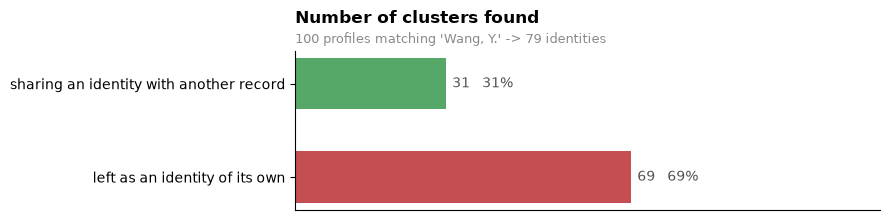

In [ ]:
identities = pd.read_excel("data/output/authors_disambiguation_cluster_elastic.xlsx")
together = int((identities["cluster_size"] > 1).sum())
stage_outcomes([
    ("sharing an identity with another record", together, "solved"),
    ("left as an identity of its own", len(identities) - together, "open"),
], "Number of clusters found",
   f"{len(identities):,} profiles matching {AUTHOR_NAME!r} -> "
   f"{identities['cluster_id'].nunique():,} identities")

In [ ]:
import itertools
from collections import defaultdict

records    = len(clustered)
identities = clustered["cluster_id"].nunique()
merged     = records - identities
pairs      = records * (records - 1) // 2
with_orcid = int(clustered["id_fix"].notna().sum())
variants   = clustered["fullname"].nunique()
population = count_elastic_authors(query=AUTHOR_NAME)
from_doi   = (int(clustered["orcid_source"].astype(str).str.startswith("doi:").sum())
              if "orcid_source" in clustered.columns else 0)


# A DOI counts as the same work as the ids it was harvested under, so co-authors
# on a paper that reached the index three times are not treated as strangers.
works = [set(as_list(row.get("author_of"))) | {f"doi:{doi}" for doi in as_list(row.get("doi"))}
         for _, row in clustered.iterrows()]

holders = defaultdict(set)
for position, keys in enumerate(works):
    for key in keys:
        holders[key].add(position)

sharing = len({pair for shared in holders.values() if len(shared) > 1
               for pair in itertools.combinations(sorted(shared), 2)})

headline = (f"**{merged} merged means no cluster was formed.** Every one of the {records} profiles is its "
            "own identity — a cluster of size 1. Clustering did not fail to run; it ran and found nothing "
            "that would justify joining any two records:"
            if merged == 0 else
            f"**{merged} of {records} records merged**, leaving {identities} identities. The evidence the "
            "rules had to go on:")

show_markdown(f"""### Reading that result

{headline}

| evidence | present? |
|---|---|
| same ORCID | {with_orcid} of the {records} profiles carry one ({from_doi} of them recovered from a DOI) |
| shared document or DOI | {sharing:,} of {pairs:,} pairs share a work |
| shared organisation | {sum(1 for row in clustered.get("current_organization", []) if as_list(row)):,} profiles have one to compare |
| distinctive name + topic overlap | the name is initials-only, so this rule is deliberately blocked |

The only thing these records have in common by name is a surname and an initial, in {variants} spelling
variants, shared by {population:,} profiles. That alone is not evidence of identity.
""")

### Reading that result

**21 of 100 records merged**, leaving 79 identities. The evidence the rules had to go on:

| evidence | present? |
|---|---|
| same ORCID | 28 of the 100 profiles carry one (28 of them recovered from a DOI) |
| shared document or DOI | 5 of 4,950 pairs share a work |
| shared organisation | 48 profiles have one to compare |
| distinctive name + topic overlap | the name is initials-only, so this rule is deliberately blocked |

The only thing these records have in common by name is a surname and an initial, in 7 spelling
variants, shared by 2,554 profiles. That alone is not evidence of identity.


### 1.4.1 How the heuristic works

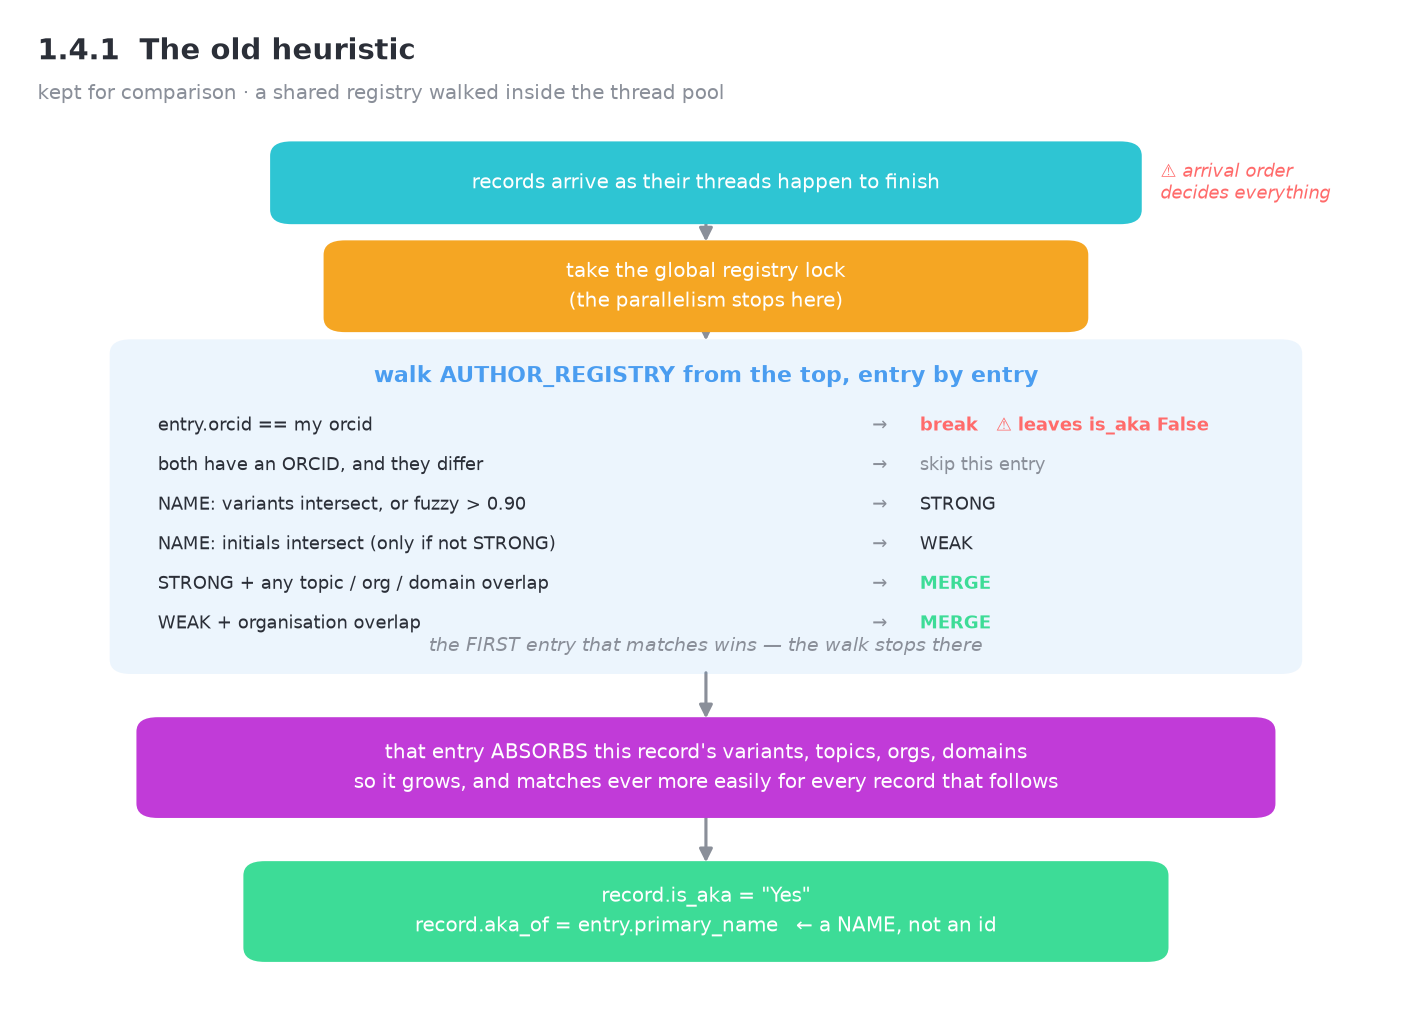

Every record is compared against a shared registry *while the thread pool is
running*, and the first entry that matches wins. Three consequences follow from
that shape — and one bug that has since been fixed.

**1. The answer depends on arrival order.** Records are consumed as futures
complete, so network timing decides which record becomes a master and which gets
absorbed. The same input produced 7 identities on one run and 8 on the next.

**2. Groups snowball.** Every merge widens the entry's name variants and context
sets, so an entry that has absorbed a few records matches almost anything that
follows. That is how most of a sample can end up behind one master.

**3. Identity is recorded as a name.** `aka_of` holds `entry.primary_name`, so two
distinct groups whose masters share a name become indistinguishable downstream —
which is why §1.4.3 reports this run's groups by watching the registry instead of
by reading `aka_of`.

**4. The ORCID shortcut discarded the strongest evidence — now fixed.** Its body
was left as `# ... [existing shortcut code] ...` followed by `break`. Breaking
left `is_aka` False, so the record fell past the loop into
`if not is_aka: AUTHOR_REGISTRY.append(...)` and was registered as a **new**
author: two records with the same ORCID stayed apart. The shortcut now merges,
as the next cell shows. The other three consequences are structural and remain.

In [ ]:
import src.functions_name as fn

# Two records, same ORCID. Nothing is more definitive than that.
same_orcid = [
    {"fullname": "J. Smith 0000-0002-1825-0097", "author_of": [], "topic": ["phys"],
     "current_organization": []},
    {"fullname": "John Smith 0000-0002-1825-0097", "author_of": [], "topic": ["phys"],
     "current_organization": []},
]

fn.AUTHOR_REGISTRY.clear()
resolved, _ = quietly(lambda rs: [fn.process_author(dict(r)) for r in rs], same_orcid)

for record in resolved:
    print(f"{record['fullname_fix']:20} orcid={record['id_fix']}  is_aka={record['is_aka']}")
print(f"registry entries: {len(fn.AUTHOR_REGISTRY)} (should be 1)")
print()
print("Both records resolve to the same person via the same ORCID. The shortcut")
print("now merges them instead of registering a second author; cluster_authors()")
print("reaches the same answer through the first rule in the evidence table above.")


Josiah Carberry      orcid=0000-0002-1825-0097  is_aka=No
Josiah Carberry      orcid=0000-0002-1825-0097  is_aka=Yes
registry entries: 1 (should be 1)

Both records resolve to the same person via the same ORCID. The shortcut
now merges them instead of registering a second author; cluster_authors()
reaches the same answer through the first rule in the evidence table above.


### 1.4.2 The same data through the heuristic

Kept for comparison. It walks a shared registry *inside* the thread pool, so the
answer depends on which future finishes first — run it twice and the counts move.

In [ ]:
import collections
import random
import src.functions_name as fn
from src.functions_name import fetch_elastic_authors

sample = fetch_elastic_authors(size=str(AUTHOR_SAMPLE), query=AUTHOR_NAME)

params(task="disambiguate", strategy="heuristic", index="triple-profiles-prod", source="elastic",
       name_searched=AUTHOR_NAME, records=len(sample), runs="2 (different input orders)")


def registry_fingerprint(entry):
    """How much an entry has absorbed. When a record is merged, exactly one entry
    grows - which is the only way to see *which* group it joined."""
    return (len(entry["full_variants"]), len(entry["initial_variants"]),
            len(entry["topics"]), len(entry["organizations"]), len(entry["domains"]))


def run_heuristic(records):
    """One heuristic pass, tracking which group each record ended up in.

    The heuristic writes `aka_of` as the master's *name*, and several masters here
    are called "Wang, Y.", so the name cannot identify a group. Watching which
    registry entry grows can, and it needs no change to the heuristic itself.
    Returns (membership, records that had to fall back to the name).
    """
    fn.AUTHOR_REGISTRY.clear()
    membership, by_name = [], 0
    for record in records:
        before = [registry_fingerprint(e) for e in fn.AUTHOR_REGISTRY]
        quietly(fn.process_author, record)
        after = [registry_fingerprint(e) for e in fn.AUTHOR_REGISTRY]

        if len(after) > len(before):
            membership.append(len(after) - 1)          # this record became a master
            continue
        grew = [index for index, (b, a) in enumerate(zip(before, after)) if b != a]
        if len(grew) == 1:
            membership.append(grew[0])
        else:                                          # absorbed without growing anything
            by_name += 1
            named = [index for index, entry in enumerate(fn.AUTHOR_REGISTRY)
                     if entry["primary_name"] == record.get("aka_of")]
            membership.append(named[0] if named else None)
    return membership, by_name


heuristic_runs, heuristic_groups, heuristic_membership = {}, {}, {}

with timed("1.4 disambiguation: heuristic"):
    for seed in (1, 2):
        shuffled = [dict(a) for a in sample]
        random.Random(seed).shuffle(shuffled)
        membership, by_name = run_heuristic(shuffled)

        heuristic_runs[seed] = shuffled
        heuristic_membership[seed] = membership
        heuristic_groups[seed] = len(fn.AUTHOR_REGISTRY)
        sizes = collections.Counter(m for m in membership if m is not None)
        print(f"  run {seed}: {len(sizes)} groups over {len(shuffled)} records · "
              f"sizes {' · '.join(str(n) for n in sorted(sizes.values(), reverse=True))}"
              + (f"  ({by_name} placed by name)" if by_name else ""))

parameters
  task          : disambiguate
  strategy      : heuristic
  index         : triple-profiles-prod
  source        : elastic
  name searched : Wang, Y.
  records       : 100
  runs          : 2 (different input orders)

  run 1: 7 groups over 100 records · sizes 92 · 2 · 2 · 1 · 1 · 1 · 1  (35 placed by name)
  run 2: 7 groups over 100 records · sizes 86 · 7 · 3 · 1 · 1 · 1 · 1  (36 placed by name)
[1.4 disambiguation: heuristic] 228.3s


### 1.4.3 Clusters as bubbles

One bubble per cluster **clustering** actually formed — a group of two or more
profile records judged to be the same person. Singletons are left out: a profile
that merged with nothing is not a cluster, and a field of identical dots says
nothing. The subtitle carries the count that matters instead: how many of the
profiles ended up inside a cluster at all.

Only clustering is drawn. It emits a `cluster_id`, so a bubble is exactly one
group; the heuristic only records the master's *name*, which several of its
masters share, so bubbles drawn from it would silently fuse separate groups. The
table under the chart reports it as group sizes that sum back to the record
count.

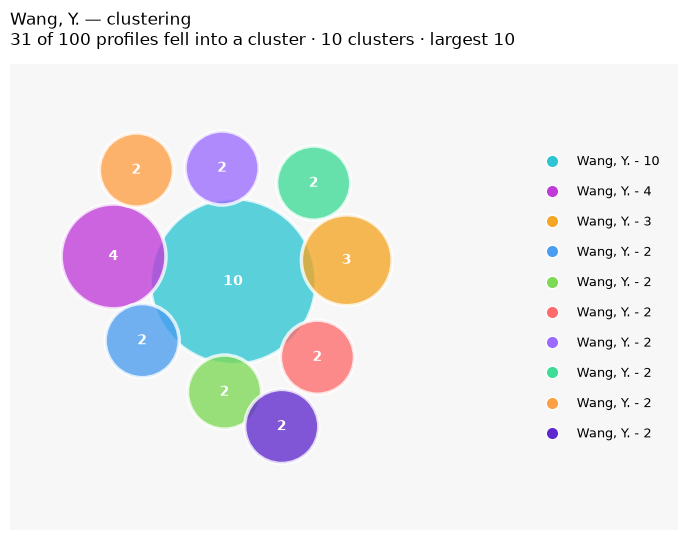

In [ ]:
import collections
import numpy as np
from matplotlib.lines import Line2D

PALETTE = ["#2ec5d3", "#c13bd8", "#f5a623", "#4a9df0", "#7ed957", "#ff6b6b",
           "#9b6bff", "#3ddc97", "#ff9f43", "#5f27cd"]


def clusters_from_clustering(frame):
    """(label, size) per cluster_id - exact, because the id is real."""
    records = frame.to_dict("records")
    sizes = collections.Counter(r["cluster_id"] for r in records)
    masters = {r["cluster_id"]: (r.get("fullname_fix") or r.get("fullname"))
               for r in records if r.get("is_aka") == "No"}
    return [(str(masters.get(cid, cid)), n) for cid, n in sizes.most_common()]


def pack(radii, gap=0.90):
    """Greedy circle packing: each bubble takes the first spiral position that
    does not overlap the ones already placed. Deterministic, and enough for the
    handful of clusters these runs produce."""
    placed = []
    for radius in radii:
        if not placed:
            placed.append((0.0, 0.0))
            continue
        for step in range(1, 4000):
            angle = step * 2.399963           # golden angle
            distance = 0.16 * np.sqrt(step)
            x, y = distance * np.cos(angle), distance * np.sin(angle)
            if all((x - px) ** 2 + (y - py) ** 2 >= (gap * (radius + pr)) ** 2
                   for (px, py), pr in zip(placed, radii)):
                placed.append((x, y))
                break
        else:
            placed.append((distance, distance))
    return placed


def bubble_chart(entries, total, title, note=None):
    """Bubbles for real clusters only; singletons are dropped by design."""
    clusters = [(label, size) for label, size in entries if size > 1]
    in_cluster = sum(size for _, size in clusters)

    fig, ax = plt.subplots(figsize=(11, 5.5))
    ax.set_facecolor("#f7f7f8")

    if not clusters:
        ax.text(.5, .5, "no cluster formed - every profile is unique",
                ha="center", va="center", fontsize=13, color="#8a8a92",
                transform=ax.transAxes)
        ax.set_xticks([]); ax.set_yticks([])
    else:
        counts = np.array([size for _, size in clusters], dtype=float)
        radii = np.sqrt(counts / counts.max())          # area proportional to records
        centres = pack(radii)

        handles = []
        for i, ((label, size), (x, y), radius) in enumerate(zip(clusters, centres, radii)):
            colour = PALETTE[i % len(PALETTE)]
            ax.add_patch(plt.Circle((x, y), radius, color=colour, alpha=.78,
                                    ec="white", lw=2.5, zorder=3))
            if radius > 0.28:
                ax.text(x, y, str(size), ha="center", va="center", zorder=4,
                        fontsize=10, color="white", fontweight="bold")
            handles.append(Line2D([0], [0], marker="o", linestyle="", markersize=9,
                                  markerfacecolor=colour, markeredgecolor="white",
                                  label=f"{label[:28]} - {size}"))

        xs = [x for x, _ in centres]; ys = [y for _, y in centres]
        pad = radii.max() * 1.25
        ax.set_xlim(min(xs) - pad, max(xs) + pad * 3.2)   # room for the legend
        ax.set_ylim(min(ys) - pad, max(ys) + pad)
        ax.set_aspect("equal")
        ax.set_xticks([]); ax.set_yticks([])
        ax.legend(handles=handles, loc="center right", frameon=False, fontsize=9,
                  labelspacing=1.3, borderpad=1, handletextpad=1.0)

    subtitle = f"{in_cluster} of {total} profiles fell into a cluster"
    if clusters:
        plural = "cluster" if len(clusters) == 1 else "clusters"
        subtitle += f" · {len(clusters)} {plural} · largest {clusters[0][1]}"
    if note:
        subtitle += f" · {note}"

    ax.set_title(f"{title}\n{subtitle}", fontsize=12, loc="left", pad=14)
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.grid(False)
    plt.tight_layout(); plt.show()
    return clusters


by_cluster = bubble_chart(clusters_from_clustering(clustered), len(clustered),
                          f"{AUTHOR_NAME} — clustering")


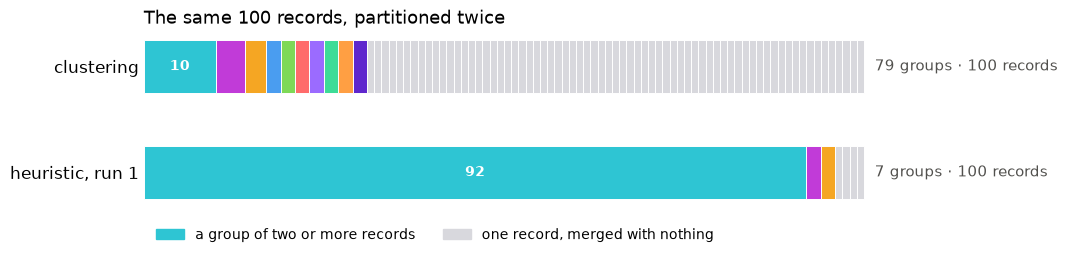

### The two answers, group by group

| | records | groups | group sizes | records accounted for |
|---|---:|---:|---|---:|
| clustering | 100 | 79 | 1×10 · 1×4 · 1×3 · 7×2 · 69×1 | 100 |
| heuristic, run 1 | 100 | 7 | 1×92 · 2×2 · 4×1 | 100 |

Both rows add up to the records that went in, so the counts can be checked rather
than taken on trust: `n×size` means *n groups of that many records*.

**The ribbon draws both rows; the bubbles above draw only clustering.** Clustering
emits a `cluster_id`, so one bubble is one group. The heuristic writes the master's
*name* into `aka_of`, and
3
of its 7 masters here are called `Wang, Y.` — bubbles drawn from
that would merge separate groups into one and invite exactly the arithmetic that does
not add up. The ribbon can show it because its heuristic row comes from watching the
registry, not from reading `aka_of`. Its 7 groups,
93 records absorbed, are the numbers above.


In [ ]:
import collections


def group_profile(sizes):
    """Group sizes as "how many groups of that size", largest first. Listing the
    sizes one by one is unreadable once there are dozens of groups of one."""
    counted = collections.Counter(sizes)
    return " · ".join(f"{count}×{size}" for size, count in sorted(counted.items(), reverse=True))


cluster_sizes = sorted(collections.Counter(clustered["cluster_id"]).values(), reverse=True)
heuristic_sizes = sorted(collections.Counter(
    m for m in heuristic_membership[1] if m is not None).values(), reverse=True)
merged_by_heuristic = sum(1 for record in heuristic_runs[1] if record.get("is_aka") == "Yes")

SINGLETON = "#d8d8dd"


def partition_ribbon(approaches, title):
    """One bar per approach, cut into its groups, largest first.

    Two bars of counts would compare two numbers; what is worth seeing here is the
    *shape* of each partition. Both bars carry the same records, so a bar's length
    is its "records accounted for" and each block is one group - which makes the
    difference between a few wide blocks and a field of hairlines the whole
    argument, without asking anyone to read it out of a table. Colour marks a group
    of two or more; grey is a record that merged with nothing.

    Everything is derived from `approaches`, so re-running on a different sample
    redraws it - there is no number written into the chart by hand.
    """
    total = max((sum(sizes) for _, sizes in approaches), default=1)

    fig, ax = plt.subplots(figsize=(11, 2.7))
    for row, (label, sizes) in enumerate(approaches):
        left = 0
        for index, size in enumerate(sizes):
            ax.barh(row, size, left=left, height=.5, zorder=3,
                    color=PALETTE[index % len(PALETTE)] if size > 1 else SINGLETON,
                    edgecolor="white", linewidth=.7)
            if size >= total * .045:          # label only a block wide enough to read
                ax.text(left + size / 2, row, str(size), ha="center", va="center",
                        fontsize=10, fontweight="bold", color="white", zorder=4)
            left += size
        ax.text(left + total * .015, row, f"{len(sizes)} groups · {sum(sizes)} records",
                va="center", fontsize=11, color="#52514e")

    ax.set_yticks(range(len(approaches)))
    ax.set_yticklabels([label for label, _ in approaches], fontsize=12)
    ax.tick_params(axis="y", length=0)
    ax.invert_yaxis()                          # clustering on top, as in the table
    ax.set_xlim(0, total * 1.3); ax.set_xticks([])
    ax.set_title(title, loc="left", fontsize=13)
    ax.grid(False)
    for side in ("top", "right", "left", "bottom"):
        ax.spines[side].set_visible(False)
    ax.legend(handles=[plt.Rectangle((0, 0), 1, 1, color=PALETTE[0]),
                       plt.Rectangle((0, 0), 1, 1, color=SINGLETON)],
              labels=["a group of two or more records", "one record, merged with nothing"],
              loc="upper left", bbox_to_anchor=(0, -.05), ncol=2, frameon=False, fontsize=10)
    plt.tight_layout(); plt.show()


partition_ribbon([("clustering", cluster_sizes), ("heuristic, run 1", heuristic_sizes)],
                 f"The same {len(clustered)} records, partitioned twice")

show_markdown(f"""### The two answers, group by group

| | records | groups | group sizes | records accounted for |
|---|---:|---:|---|---:|
| clustering | {len(clustered)} | {len(cluster_sizes)} | {group_profile(cluster_sizes)} | {sum(cluster_sizes)} |
| heuristic, run 1 | {len(heuristic_runs[1])} | {len(heuristic_sizes)} | {group_profile(heuristic_sizes)} | {sum(heuristic_sizes)} |

Both rows add up to the records that went in, so the counts can be checked rather
than taken on trust: `n×size` means *n groups of that many records*.

**The ribbon draws both rows; the bubbles above draw only clustering.** Clustering
emits a `cluster_id`, so one bubble is one group. The heuristic writes the master's
*name* into `aka_of`, and
{collections.Counter(e["primary_name"] for e in fn.AUTHOR_REGISTRY).most_common(1)[0][1]}
of its {heuristic_groups[1]} masters here are called `{AUTHOR_NAME}` — bubbles drawn from
that would merge separate groups into one and invite exactly the arithmetic that does
not add up. The ribbon can show it because its heuristic row comes from watching the
registry, not from reading `aka_of`. Its {heuristic_groups[1]} groups,
{merged_by_heuristic} records absorbed, are the numbers above.
""")


Which is right? Neither is provably correct without ground truth — but a false
merge silently fuses two researchers' publication lists, while a missed merge
leaves a duplicate for a human to spot. This pipeline prefers the second, so
with no evidence it splits.

## 1.5 Malformed full names: the rest of the surface

§1.1–1.3 each take one *kind* of broken name — an ORCID sitting inside it, an empty
string, a URL or bare digits — and carry it the whole way: a query that selects the
population, a label from `classify_name_problem`, and a repair. Those three are not the
only ways a `fullname` is malformed; they are the ways that have been worked on.

The rest are grouped here as **malformed fullname**. This section does not fix them —
none of them has a repair — it sizes each one against the index and says which of the
three levels it already has:

* **selected** — a query in `NAME_FILTER_QUERIES`, so a pipeline can be pointed at it
* **classified** — a label from `classify_name_problem`, so a report can separate it
* **repaired** — a code path that turns it into a better name

Every count below is measured against `triple-profiles-prod` when the cell runs, so the
table follows the index rather than a note taken once.


In [ ]:
from src.es_helpers import es_search
from src.functions_name import (PROFILES_INDEX, MALFORMED_NAME_QUERY, NAME_FILTER_QUERIES,
                                classify_name_problem)

# A non-breaking space has to be written as an escape: typed as a literal it is
# indistinguishable from a plain space, and ".* .*" then matches 23.5M names
# instead of 23 thousand.
NBSP = "\u00a0"


def matching(pattern):
    """A regexp over the whole fullname. `flags=NONE` disables Lucene's operators -
    with them on, `@` means "any string", so a probe for an email address in the
    name quietly matches every profile in the index."""
    return {"regexp": {"fullname.keyword": {"value": pattern, "flags": "NONE"}}}


def any_of(*queries):
    return {"bool": {"should": list(queries), "minimum_should_match": 1}}


def excluding(query, unwanted):
    return {"bool": {"must": [query], "must_not": [unwanted]}}


# One row per way a fullname is malformed. `probe` is deliberately a rough
# selector, not the detector these would eventually need: it is here to size the
# population, and each is noted below where it over- or under-counts.
MALFORMED_KINDS = [
    ("url", "URL in the name", matching(".*(https?://|www\\.).*"),
     "http://nationalgeographic.grid.id"),
    ("digits", "Stray digits", matching(".*[0-9].*"),
     "Nebrija, Antonio de, 1444-1522"),
    ("too_short", "Too short (<= 2 characters)",
     excluding({"range": {"fullname_length": {"lte": 2}}}, {"term": {"fullname.keyword": ""}}),
     "."),
    ("punctuation", "Punctuation / multi-author", matching(".*(;|::|//|#).*"),
     "Smith, J.; Jones, A. :: Brown, K."),
    ("abnormal_case", "Abnormal casing (UPPER / lower)",
     any_of(matching("[A-Z][A-Z .'\\-]{3,}"), matching("[a-z][a-z .'\\-]{3,}")),
     "EDGAR V. ANDALECIO"),
    ("email", "Email in the name", matching(".*@.*"),
     "Ivanov, Stanislav; stanislav.ivanov@vumk.eu"),
    ("placeholder", "Placeholder / dummy value",
     {"terms": {"fullname.keyword": ["s.n.", "S.n.", "unknown", "Unknown", "NN", "anonymous",
                                     "Anonymous", "Not Available", "n/a", "N/A", "author", "Author"]}},
     "s.n."),
    ("institution", "Institution, not a person",
     matching(".*(University|Universit.|Institut|Institute|College|School|GmbH|Company|"
              "Ministry|Cent(er|re)|Society|Museum).*"),
     "University of Alberta"),
    ("single_token", "Mononym / single token",
     excluding(matching("[^ ,]+"), {"term": {"fullname.keyword": ""}}),
     "Plato"),
    ("encoding", "Encoding artefacts",
     any_of(matching(".*" + NBSP + ".*"), matching(".*Ã.*"), matching(".*â€.*"), matching(".*�.*")),
     "Cristina Del" + NBSP + "Biaggio"),
]


def profiles_matching(query):
    return es_search({"size": 0, "track_total_hits": True, "query": query},
                     index=PROFILES_INDEX)["hits"]["total"]["value"]


with timed("1.5 malformed names: sizing"):
    surveyed = []
    for code, label, probe, example in MALFORMED_KINDS:
        total = profiles_matching(probe)
        # What the four existing filters would not hand to any repair pipeline.
        missed = profiles_matching(excluding(probe, MALFORMED_NAME_QUERY))
        surveyed.append({"code": code, "label": label, "example": example,
                         "profiles": total, "missed": missed,
                         "verdict": classify_name_problem(example)})
    surveyed.sort(key=lambda row: -row["missed"])

    selected_today = profiles_matching(MALFORMED_NAME_QUERY)
    group_total = profiles_matching(any_of(*(probe for _, _, probe, _ in MALFORMED_KINDS)))
    group_missed = profiles_matching(
        excluding(any_of(*(probe for _, _, probe, _ in MALFORMED_KINDS)), MALFORMED_NAME_QUERY))

fig, ax = plt.subplots(figsize=(10, 4.6))
rows = list(reversed(surveyed))
covered = [row["profiles"] - row["missed"] for row in rows]
missed = [row["missed"] for row in rows]
labels = [row["code"] for row in rows]

ax.barh(labels, covered, color=OK, label=f"a filter already selects it ({', '.join(NAME_FILTER_QUERIES)})")
ax.barh(labels, missed, left=covered, color=BAD, label="no filter selects it")
for index, row in enumerate(rows):
    ax.text(row["profiles"], index, f"  {row['profiles']:,}", va="center", fontsize=9)
ax.set_xlabel("profiles")
ax.set_title(f"Malformed fullname: {group_missed:,} profiles no current filter reaches")
ax.set_xlim(0, max(row["profiles"] for row in rows) * 1.18)
ax.grid(axis="y", visible=False)
ax.legend(loc="lower right", fontsize=9)
plt.tight_layout(); plt.show()

show_markdown(f"""### Malformed fullname: what each filter reaches

`NAME_FILTER_QUERIES` offers {len(NAME_FILTER_QUERIES)} selections — {', '.join(f'`{k}`' for k in NAME_FILTER_QUERIES)} —
and together they select **{selected_today:,} profiles**. The kinds below are all *malformed
fullname* too, and the probes for them reach **{group_total:,}**, of which
**{group_missed:,} no current filter selects at all**.

| kind | profiles | not selected | `classify_name_problem` says | example |
|---|---:|---:|---|---|
""" + "".join(
    f"| {row['label']} | {row['profiles']:,} | {row['missed']:,} | `{row['verdict']}` | `{row['example'][:44]}` |\n"
    for row in surveyed) + f"""
`classify_name_problem` returns `ok` for every kind it has no rule for, so that column is
the honest inventory: a kind reading `ok` is invisible to the reports as well as to the
filters. Only §1.1–1.3 (`empty`, ORCID in the name, URL or bare digits) have a detector,
a selection **and** a repair.

Two of the rows are already partly reachable rather than absent:

* **Stray digits** — `junk` selects on `{{"regexp": {{"fullname.keyword": "[0-9]+"}}}}`, and a
  Lucene regexp is anchored, so it matches names that are *entirely* digits. That is
  {profiles_matching(matching("[0-9]+")):,} profiles against
  {profiles_matching(matching(".*[0-9].*")):,} that carry a digit anywhere — a lifespan like
  `1444-1522` is never selected.
* **URL** — `junk` matches the token `http`, so a bare `www.` host is missed, and
  `clean_messy_name` strips `https?://` but not `www.`.

The probes are rough by design: `institution` is a keyword guess, `abnormal_case` is
ASCII-only and so a floor, and `single_token` counts any value with no space or comma, so
it overlaps the others. They size the problem; they are not the detectors these kinds
would need.
""")


---
# 2. Licenses

`triple-documents-prod` holds the documents, and most of them have no usable
license — the single largest data-quality gap in GoTriple.

## 2.1 What "no usable license" means

`license` is an array, and three different values all mean *nothing usable*:

In [ ]:
from src.es_helpers import es_search, DOCUMENTS_INDEX

def documents_matching(query):
    """A straight count, for the two shapes build_license_query does not cover."""
    return es_search({"size": 0, "track_total_hits": True, "query": query},
                     index=DOCUMENTS_INDEX, timeout=180)["hits"]["total"]["value"]

buckets = [(f"`{value}`" if value else '`""`', count_elastic_documents(value))
           for value in ("undefined", "other", "")]
buckets.append(("field absent",
                documents_matching({"bool": {"must_not": [{"exists": {"field": "license"}}]}})))
overlap = documents_matching({"bool": {"must": [{"term": {"license": "other"}},
                                                {"term": {"license": "undefined"}}]}})
unresolved = count_elastic_documents("unresolved")

show_markdown(
    f"`triple-documents-prod` holds **{documents_matching({'match_all': {}}):,} documents**, "
    f"**{unresolved:,} of them with no usable license**. §2.3 works on `DOCUMENT_SAMPLE` = "
    f"**{min(DOCUMENT_SAMPLE, unresolved):,}** of those.\n\n"
    "| value | documents |\n|---|---:|\n"
    + "".join(f"| {label} | {count:,} |\n" for label, count in buckets)
    + f"\nThey are **one population, not three**: {overlap:,} documents carry both `other` and "
      "`undefined` at once, so adding the buckets double-counts. The pipeline treats them as a "
      'single "unresolved" group.')

`triple-documents-prod` holds **40,292,937 documents**, **38,382,096 of them with no usable license**. §2.3 works on `DOCUMENT_SAMPLE` = **100** of those.

| value | documents |
|---|---:|
| `undefined` | 37,204,649 |
| `other` | 1,715,533 |
| `""` | 0 |
| field absent | 167 |

They are **one population, not three**: 538,253 documents carry both `other` and `undefined` at once, so adding the buckets double-counts. The pipeline treats them as a single "unresolved" group.

In [ ]:
print(f"documents with no usable license: {count_elastic_documents('unresolved'):,}")
print(json.dumps(build_license_query("unresolved"), indent=2))

documents with no usable license: 38,382,096
{
  "bool": {
    "should": [
      {
        "terms": {
          "license": [
            "other",
            "undefined",
            ""
          ]
        }
      },
      {
        "bool": {
          "must_not": [
            {
              "exists": {
                "field": "license"
              }
            }
          ]
        }
      }
    ],
    "minimum_should_match": 1
  }
}


## 2.2 The recovery strategy

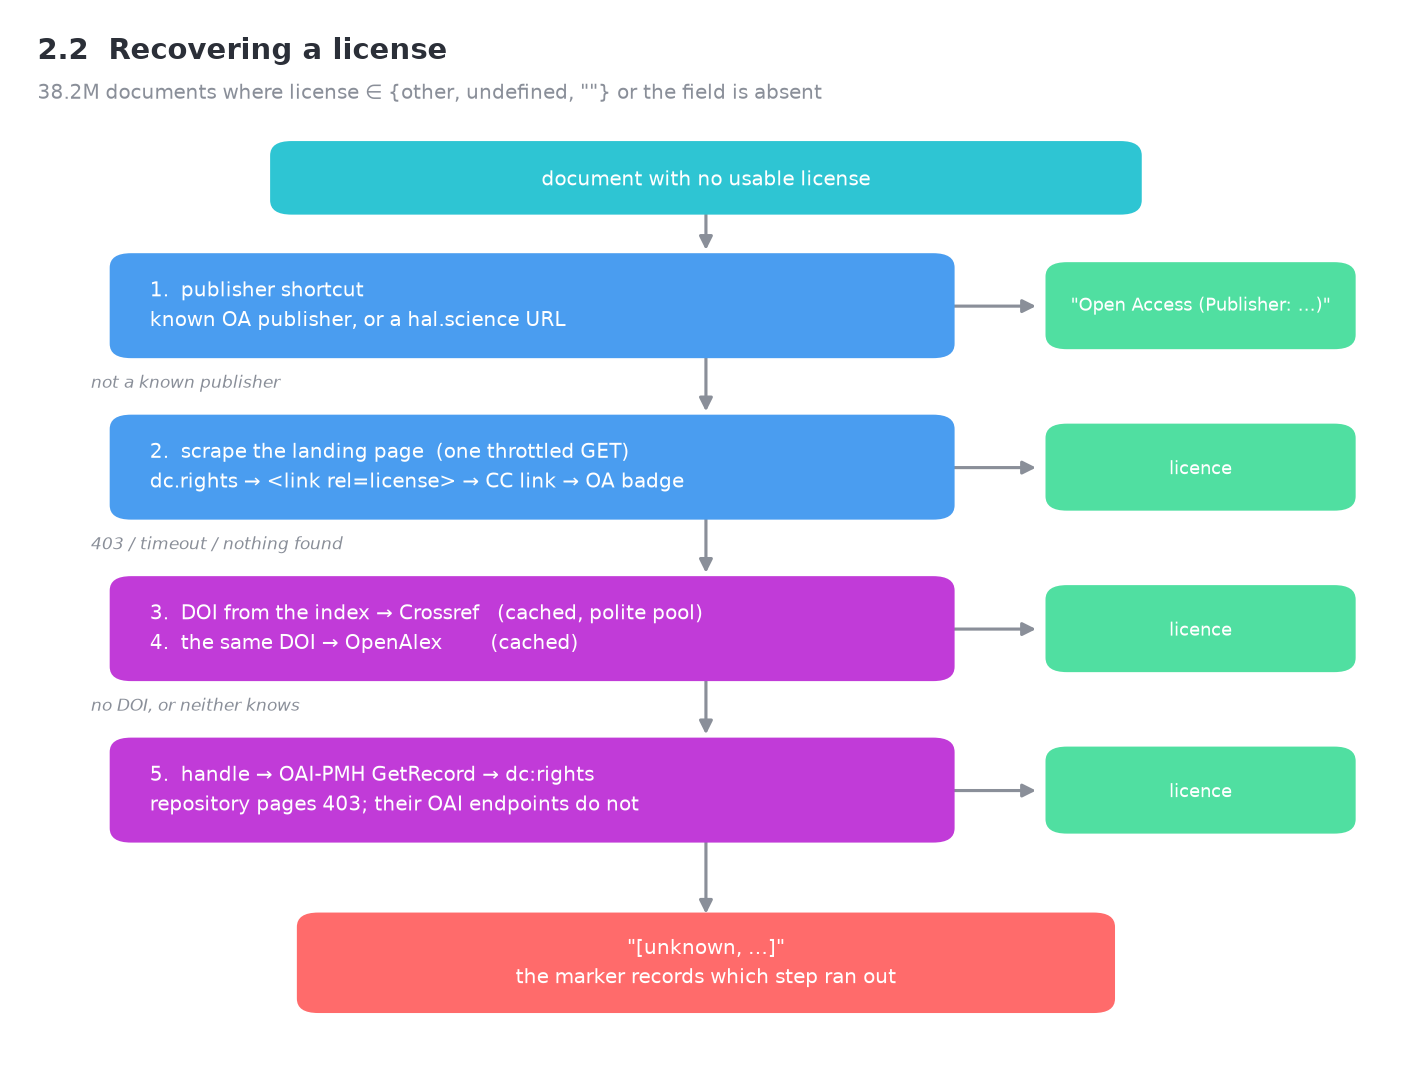

Steps 3–5 exist because scraping fails so often: **12.8% of landing pages answer
403**, concentrated in Cloudflare-protected hosts (doaj.org, hdl.handle.net,
ncbi, cairn). A realistic User-Agent recovered only 1 of 51 — these are
infrastructure blocks, not bot-sniffing — so the fix was to stop scraping those
and ask the metadata APIs instead, which lifted 403 recovery to 57% and overall recovery from 63.5% to 69%.

## 2.3 Run

## 2.3.1 Step 0 — classify `original_license` locally

Two fields, two jobs:

| field | role | state |
|---|---|---|
| `license` | GoTriple code (`lic_creative-commons`, `lic_cairn`, …) | ~92 % `undefined` |
| `original_license` | raw harvest text / URI | filled on ~11 % ; **~31.4 M (89 %) empty** |

**Why original_license first?** The index already contains the raw string that produced the broken `license`. Reading it costs nothing (local), whereas every HTTP GET on the 38 M unresolved documents accumulates ~82 days of wall clock. The three natures that appear in `original_license` are:

1. **Access**, not a licence — `info:eu-repo/semantics/openAccess`, `free access`, `restrictedAccess`. Goes to `conditions_of_access`, not `license`.
2. **Real licences, aliased** — CC BY 4.0 stored as ~10 distinct URL variants (http/https, trailing slash, `/legalcode`, local labels). One SPDX id collapses all of them.
3. **Repository legalese** — HAL authorisation, EconStor Nutzungsbedingungen, Cairn. Cairn maps to `lic_cairn`; the rest are `repository` or `copyright`, not a usable code.

**Paulo's scraper** called `'creative_commons' in original_license` — that token never appears in a harvested CC URL, so every CC URL went to HTTP. `process_document` also passed `license` (always `undefined`) instead of `original_license` into the scraper.

> **Population for this run:** unresolved (`license` = `other` / `undefined` / `""`) _and_ `original_license` present. This is the highest-yield local subset.
> A separate population (unresolved, `original_license` absent) still needs HTTP — that is §2.3 (step 1).


In [ ]:
from src.functions_license import build_license_query, count_elastic_documents

n_with_ol = count_elastic_documents('unresolved', original_license='present')
n_without_ol = count_elastic_documents('unresolved', original_license='absent')
show_markdown(
    f"Unresolved **with** `original_license` (step 0 target): **{n_with_ol:,}**\n\n"
    f"Unresolved **without** `original_license` (step 1, HTTP): **{n_without_ol:,}**"
)
print(json.dumps(build_license_query('unresolved', original_license='present'), indent=2))


In [ ]:
from src.functions_license import count_elastic_documents

params(
    task='license local match (original_license)',
    index='triple-documents-prod',
    source='elastic',
    selection='unresolved AND original_license present',
    records_requested=DOCUMENT_SAMPLE,
    population=f"{count_elastic_documents('unresolved', original_license='present'):,}",
    http=False,
)

with timed('2.3.1 original_license match'):
    _, output231 = quietly(
        pipelines.run_license_match_pipeline,
        num_docs=str(DOCUMENT_SAMPLE), source='elastic',
    )

digest(output231)
show_query('triple-documents-prod', title='query executed')


In [ ]:
match_df = pd.read_excel('data/output/license_match_elastic.xlsx')

kinds = match_df['license_kind'].fillna('empty').astype(str)
licence_mask = match_df['license_fix'].fillna('').astype(str).str.startswith('lic_')

n_total   = len(match_df)
n_licence = int(licence_mask.sum())
n_access  = int((kinds == 'access').sum())
n_repo    = int(kinds.isin(['repository', 'copyright']).sum())
n_unmapped = int(kinds.isin(['unmapped', 'empty']).sum())

show_markdown(
    f"| outcome | documents | share |\n"
    f"|---|---:|---:|\n"
    f"| real licence (`lic_*`) | {n_licence:,} | {n_licence/n_total*100:.1f}% |\n"
    f"| access only (→ `conditions_of_access`) | {n_access:,} | {n_access/n_total*100:.1f}% |\n"
    f"| repository / copyright | {n_repo:,} | {n_repo/n_total*100:.1f}% |\n"
    f"| unmapped / no original_license | {n_unmapped:,} | {n_unmapped/n_total*100:.1f}% |\n"
)

print('Top SPDX codes found:')
spdx_col = match_df.loc[licence_mask, 'spdx'].fillna('').astype(str)
spdx_col = spdx_col[spdx_col != '']
print(spdx_col.value_counts().head(10).to_string())


In [ ]:
match_df = pd.read_excel('data/output/license_match_elastic.xlsx')

kinds = match_df['license_kind'].fillna('empty').astype(str)
licence_mask = match_df['license_fix'].fillna('').astype(str).str.startswith('lic_')
n_total   = len(match_df)
n_licence = int(licence_mask.sum())
n_access  = int((kinds == 'access').sum())
n_repo    = int(kinds.isin(['repository', 'copyright']).sum())
n_unmapped = int(kinds.isin(['unmapped', 'empty']).sum())

stage_outcomes(
    [
        ('real licence recovered (lic_*)', n_licence, 'solved'),
        ('access only (conditions_of_access)', n_access, 'settled'),
        ('repository / copyright legalese', n_repo, 'settled'),
        ('unmapped or no original_license', n_unmapped, 'open'),
    ],
    '2.3.1  What original_license local match settled',
    f'{n_total:,} documents: unresolved AND original_license present',
)


In [ ]:
params(task="license recovery", index="triple-documents-prod", source="elastic",
       selection='license in {other, undefined, ""} or absent',
       records_requested=DOCUMENT_SAMPLE, population=f"{count_elastic_documents('unresolved'):,}",
       max_workers=10)

with timed("2.3 licenses"):
    _, output = quietly(pipelines.run_license_pipeline,
                        num_docs=str(DOCUMENT_SAMPLE), source="elastic", max_workers=10)

show_query("documents", "\nselection query")
print()
digest(output)

parameters
  task              : license recovery
  index             : triple-documents-prod
  source            : elastic
  selection         : license in {other, undefined, ""} or absent
  records requested : 100
  population        : 38,382,096
  max workers       : 10

[2.3 licenses] 18.5s

selection query — index: triple-documents-prod
{
  "size": 100,
  "query": {
    "bool": {
      "should": [
        {
          "terms": {
            "license": [
              "other",
              "undefined",
              ""
            ]
          }
        },
        {
          "bool": {
            "must_not": [
              {
                "exists": {
                  "field": "license"
                }
              }
            ]
          }
        }
      ],
      "minimum_should_match": 1
    }
  },
  "sort": [
    {
      "id": "asc"
    }
  ]
}

--- STARTING DOCUMENT LICENSE PIPELINE ---
-> License data saved to '/Users/paulopiimenta/projects/lumen/lumen-metadata-t43/da

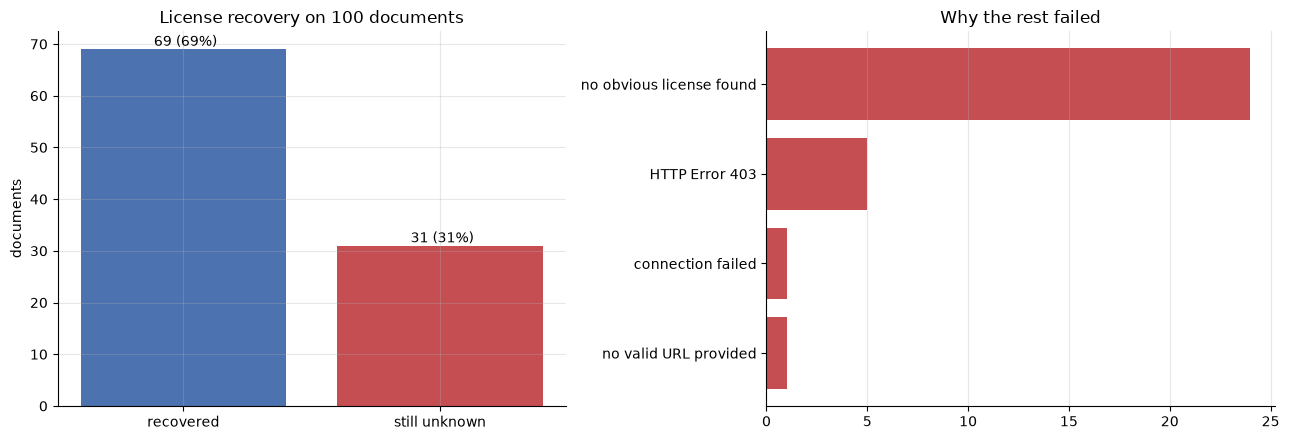

In [ ]:
licenses = pd.read_excel("data/output/license_fix_elastic.xlsx")
result = licenses["scrapped_license"].astype(str)
searched = result[result != "Already classified"]
found = searched[~searched.str.startswith("[unknown")]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].bar(["recovered", "still unknown"], [len(found), len(searched) - len(found)], color=[OK, BAD])
axes[0].set_title(f"License recovery on {len(searched)} documents")
axes[0].set_ylabel("documents")
for i, v in enumerate([len(found), len(searched) - len(found)]):
    axes[0].text(i, v, f" {v} ({100*v/len(searched):.0f}%)", ha="center", va="bottom")

reasons = searched[searched.str.startswith("[unknown")].value_counts().head(6)[::-1]
if len(reasons):
    axes[1].barh([r.strip("[]").replace("unknown, ", "")[:34] for r in reasons.index],
                 reasons.values, color=BAD)
axes[1].set_title("Why the rest failed")
axes[1].grid(axis="y", visible=False)
plt.tight_layout(); plt.show()

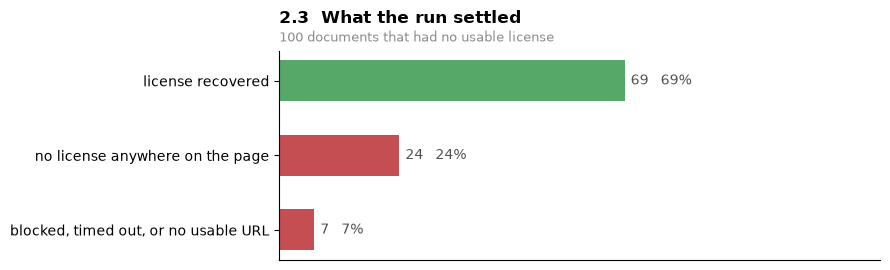

In [ ]:
result = pd.read_excel("data/output/license_fix_elastic.xlsx")["scrapped_license"].astype(str)
searched = result[result != "Already classified"]
unknown = searched[searched.str.startswith("[unknown")]
no_license = int(unknown.str.contains("no obvious license").sum())
stage_outcomes([
    ("license recovered", len(searched) - len(unknown), "solved"),
    ("no license anywhere on the page", no_license, "open"),
    ("blocked, timed out, or no usable URL", len(unknown) - no_license, "open"),
], "2.3  What the run settled", f"{len(searched):,} documents that had no usable license")

## 2.4 Empty DOI

The licence pipeline already needs a DOI when the landing page returns 403.
An empty string in `doi` makes that fallback a no-op: `exists: doi` looks
healthy, Crossref cannot be called with `""`.

This is the ingest bug from the metadata analysis, not a third problem class.
Empty-string and a missing field stay separate counts — collapsing them hides
the mapping error behind a genuine unknown.

Cheapest evidence first. Scraping 20 M pages is the same wall as §2.3 (~82 days)
and the HTML cites *other* papers, so a regex over the body is not a source.

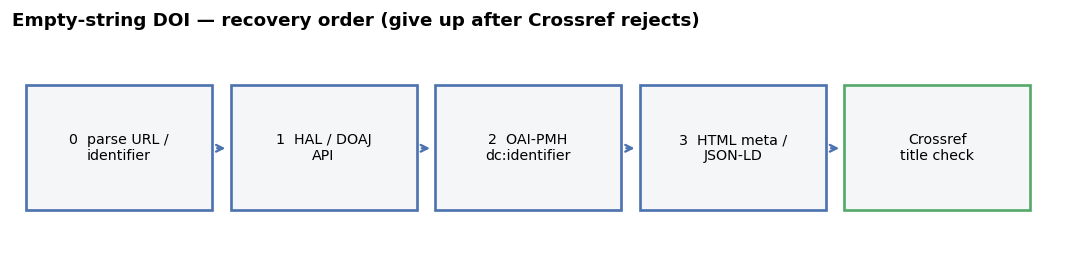


In [1]:
from src.functions_doi import build_doi_query, count_elastic_doi_documents
from src.es_helpers import es_search, DOCUMENTS_INDEX

def documents_matching(query):
    return es_search({"size": 0, "track_total_hits": True, "query": query},
                     index=DOCUMENTS_INDEX, timeout=180)["hits"]["total"]["value"]

empty = count_elastic_doi_documents("empty_string")
absent = count_elastic_doi_documents("absent")
with_page = count_elastic_doi_documents("with_landing_page")
corpus = documents_matching({"match_all": {}})

show_markdown(
    f"`triple-documents-prod` holds **{corpus:,} documents**. "
    f"**{empty:,}** have an empty-string `doi` (the ingest bug). "
    f"**{absent:,}** have no `doi` field at all. "
    f"**{with_page:,}** of those unusable rows still expose `main_entity_of_page`.\n\n"
    "| situation | documents | this run |\n"
    "|---|---:|---:|\n"
    f"| empty-string doi | {empty:,} | {min(DOI_SAMPLE, empty):,} |\n"
    f"| field absent | {absent:,} | — |\n"
    f"| unusable and a landing page | {with_page:,} | — |\n\n"
    "§2.4 runs on **empty-string**, not on the missing-field set. DNB is ~98 % "
    "empty-string and often has no URL: those rows will show up as `no landing page`, "
    "which is a settled limit of this path, not a failed scrape."
)

print("documents with empty-string doi:", f"{empty:,}")
print(json.dumps(build_doi_query("empty_string"), indent=2))


`triple-documents-prod` — **23,203,138** empty-string `doi`, **2,006,418** field absent, **23,949,627** unusable with a landing page.

| situation | documents | this run |
|---|---:|---:|
| empty-string doi | 23,203,138 | 500 |
| field absent | 2,006,418 | — |
| unusable and a landing page | 23,949,627 | — |

§2.4 runs on **empty-string**. DNB is often `no landing page` — a limit of this path, not a failed scrape.

documents with empty-string doi: 23,203,138
{
  "term": {
    "doi": ""
  }
}


### The recovery strategy

```
doi is "" (or absent)
        │
        ▼
0  already in identifier / URL?  ──yes──► Crossref/DataCite: exists + title match ──ok──► doi_fix
        │ no
        ▼
1  HAL / DOAJ API (if the id says so)
        │
        ▼
2  OAI-PMH GetRecord → dc:identifier   (handles; HTML often 403)
        │
        ▼
3  HTML <meta citation_doi> / JSON-LD only
        │
        ▼
give up
```

**Checking the landing page first would be wasted work** on the same hosts §2.3
already lost to Cloudflare (`doaj.org`, `hdl.handle.net`). DOAJ and HAL have
JSON APIs; handles usually still answer OAI-PMH when the web front end does not.

**A DOI found in the HTML body is not evidence.** Reference lists, related
articles and widgets put other `10.` strings on the page. Only `citation_doi`,
`dc.identifier`, `prism.doi` and JSON-LD `@id` / `sameAs` are read.

**Crossref and DataCite are checks, not a search.** The candidate is asked on
Crossref `/works/{doi}`, then DataCite `/dois/{doi}` if Crossref 404s
(institutional prefixes such as `10.7939`). The title must match `headline`.
We do not send title + author to *invent* a DOI — that is how you attach the
wrong paper (homonym, preprint vs version of record).


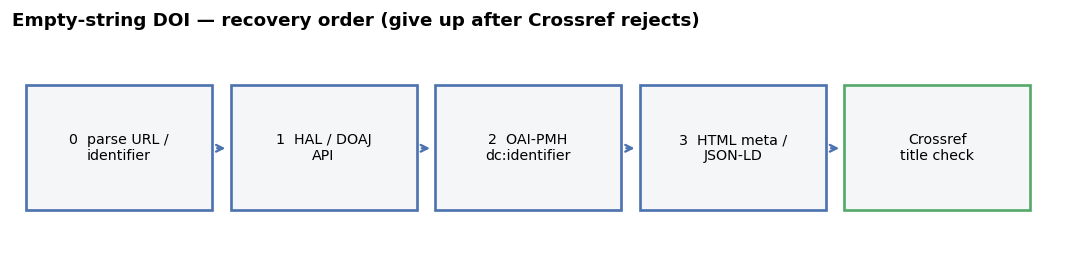

In [1]:
fig, ax = plt.subplots(figsize=(11.2, 2.4))
ax.set_xlim(0, 11.2); ax.set_ylim(0, 2.4); ax.axis("off")
steps = [
    (0.15, "0  parse URL /\nidentifier"),
    (2.35, "1  HAL / DOAJ\nAPI"),
    (4.55, "2  OAI-PMH\ndc:identifier"),
    (6.75, "3  HTML meta /\nJSON-LD"),
    (8.95, "Crossref /\nDataCite"),
]
for i, (x, lab) in enumerate(steps):
    ax.add_patch(plt.Rectangle((x, 0.55), 2.0, 1.35, facecolor="#f4f6f8",
                               edgecolor=ALT if i == 4 else OK, linewidth=1.6))
    ax.text(x + 1.0, 1.22, lab, ha="center", va="center", fontsize=8.5)
    if i < 4:
        ax.annotate("", xy=(steps[i + 1][0] - 0.02, 1.22), xytext=(x + 2.02, 1.22),
                    arrowprops=dict(arrowstyle="->", color=OK, lw=1.4))
ax.set_title("Empty-string DOI — recovery order (give up after Crossref/DataCite reject)",
             loc="left", fontweight="bold", fontsize=11, pad=8)
plt.tight_layout(); plt.show()


### Worked case: a Handle is not a DOI, DataCite is

The first ids in `search_after id asc` are ISIDORE Handles
(`hdl.handle.net/11089/…`, `10402/era.…`). Route 0 finds nothing: `identifier`
is `1000` or `10402/era.10402`, not `10.…`. The Handle API returns a landing
URL, not a DOI.

One of those Handles still has a DOI on the landing page. Document
`10402_era.10402` → `http://hdl.handle.net/10402/era.10402` exposes
`10.7939/R3XP6V886` in `citation_doi` / JSON-LD. That prefix is University of
Alberta Library, registered at **DataCite**. Crossref `/works/{doi}` is 404, so
the n=50 run stored `rejected: not in Crossref`. The cell below replays the
same record: scrape, Crossref, DataCite, then `recover_doi`.


In [1]:
from src.es_helpers import DOCUMENTS_INDEX
from src.functions_doi import (
    fetch_crossref_work, fetch_datacite_work, fetch_elastic_doi_by_id,
    first_http_url, scrape_doi_from_html, document_title, validate_doi,
)

CASE_ID = "10402_era.10402"
doc = fetch_elastic_doi_by_id(CASE_ID)
if doc is None:
    raise SystemExit(f"document {CASE_ID!r} not in {DOCUMENTS_INDEX}")

url = first_http_url(doc)
title = document_title(doc)
scraped, scrape_note = scrape_doi_from_html(url)
candidate = scraped[0] if scraped else ""
crossref = fetch_crossref_work(candidate) if candidate else None
datacite = fetch_datacite_work(candidate) if candidate else None
ok, reason = validate_doi(candidate, title) if candidate else (False, "no candidate")
doi_fix = candidate if ok else ""
doi_source = "html meta/json-ld" if ok else f"rejected: {reason}"

def registry_label(work):
    if work is None:
        return "unreachable"
    if not work:
        return "404"
    theirs = (work.get("title") or [""])[0]
    return f"200 — {theirs}" if theirs else "200 — no title"

show_markdown(
    f"Document `{CASE_ID}` — empty-string `doi`, provider "
    f"`{doc.get('provider')}`.\n\n"
    "| step | result |\n"
    "|---|---|\n"
    f"| `identifier` | `{doc.get('identifier')}` |\n"
    f"| landing URL | `{url}` |\n"
    f"| `headline` | {title} |\n"
    f"| HTML `{scrape_note}` | `{candidate or '—'}` |\n"
    f"| Crossref `/works/{{doi}}` | {registry_label(crossref)} |\n"
    f"| DataCite `/dois/{{doi}}` | {registry_label(datacite)} |\n"
    f"| `doi_fix` | **`{doi_fix or '—'}`** via `{doi_source}` |\n"
)


Document `10402_era.10402` — empty-string `doi`, provider `['isidore']`.

| step | result |
|---|---|
| `identifier` | `['10402/era.10402']` |
| landing URL | `http://hdl.handle.net/10402/era.10402` |
| `headline` | The "Doppelbegabung" of Hector Berlioz: music and literature |
| HTML `html meta/json-ld` | `10.7939/R3XP6V886` |
| Crossref `/works/{doi}` | 404 |
| DataCite `/dois/{doi}` | 200 — The "Doppelbegabung" of Hector Berlioz: music and literature |
| `doi_fix` | **`10.7939/R3XP6V886`** via `html meta/json-ld` |


In [1]:
from src.functions_doi import count_elastic_doi_documents

params(task="doi recovery", index="triple-documents-prod", source="elastic",
       selection='doi.keyword / doi == ""',
       records_requested=DOI_SAMPLE,
       population=f"{count_elastic_doi_documents('empty_string'):,}",
       max_workers=10)

with timed("2.4 empty doi"):
    _, output = quietly(pipelines.run_doi_pipeline,
                        num_docs=str(DOI_SAMPLE), kind="empty_string",
                        max_workers=10)

show_query("documents", "\nselection query")
print()
digest(output)


parameters
  task               : doi recovery
  index              : triple-documents-prod
  selection          : doi == empty string
  records requested  : 500
  population         : 23,203,138
  max workers        : 10

[2.4 empty doi] 789.2s

DOI RECOVERY SUMMARY
-> Documents in batch           : 500
-> DOIs recovered               : 459 / 500 (91.8%)
-> Still empty                  : 41

--- What recovered them ---
     * html meta/json-ld: 459

--- Why the rest failed ---
     * not recovered: 35
     * connection failed: 3
     * HTTP 404: 2
     * HTTP 502: 1


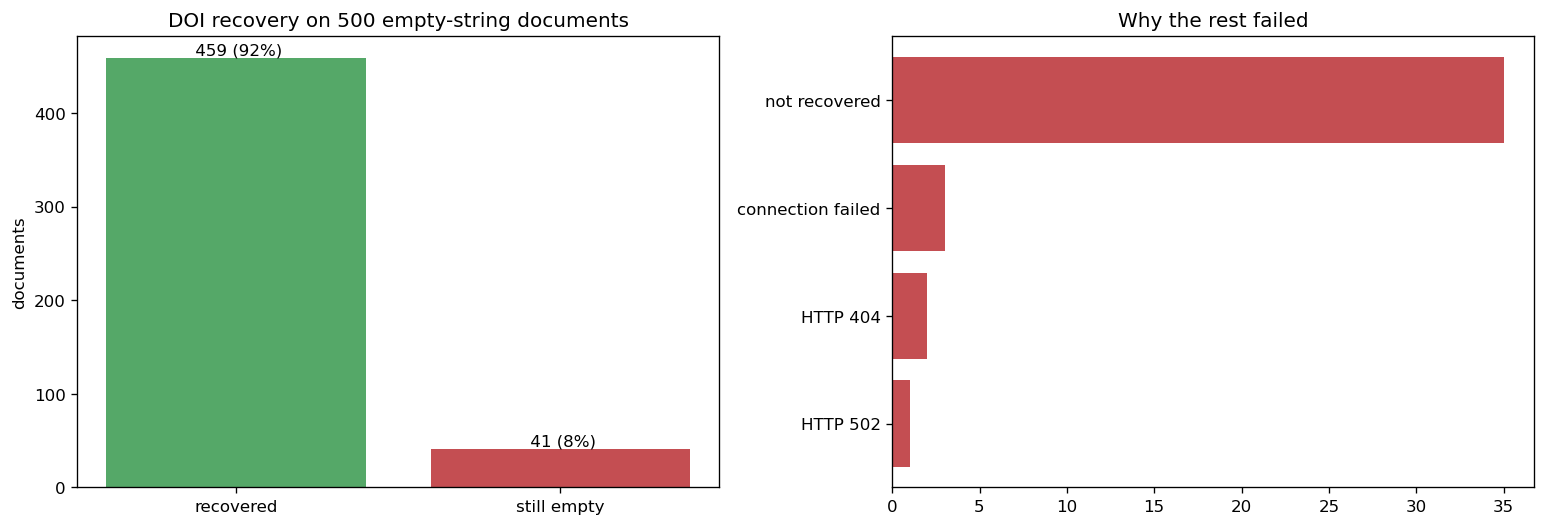

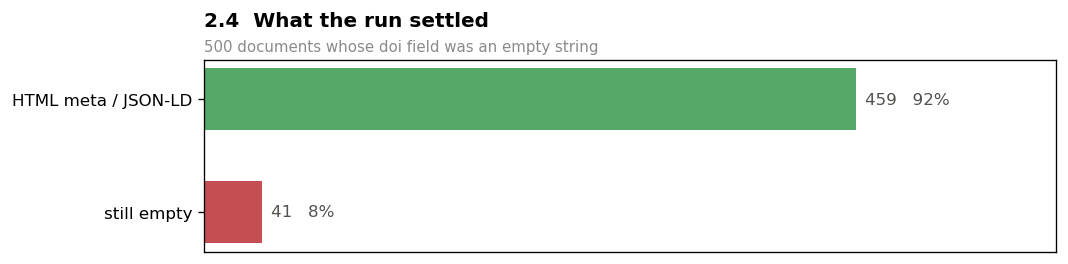

             id           doi_fix        doi_source
10402_era.10971 10.7939/R3XK85082 html meta/json-ld
10402_era.10669 10.7939/R3H70851Z html meta/json-ld
10402_era.11729 10.7939/R3571804F html meta/json-ld
10402_era.11497 10.7939/R3TD9NJ1C html meta/json-ld
10402_era.11434 10.7939/R3SB3X38Z html meta/json-ld
10402_era.11862 10.7939/R3GH9BH71 html meta/json-ld
10402_era.10402 10.7939/R3XP6V886 html meta/json-ld
10402_era.13143 10.7939/R3862BM49 html meta/json-ld


In [1]:
dois = pd.read_excel("data/output/doi_fix_elastic.xlsx")
source = dois["doi_source"].fillna("not recovered").astype(str)
fixed = dois["doi_fix"].fillna("").astype(str).str.startswith("10.")

def n(label):
    return int((source == label).sum())

solved = int(fixed.sum())
settled = n("no landing page")
open_ = len(dois) - solved - settled
total = len(dois) or 1

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].bar(["recovered", "still empty"], [solved, total - solved], color=[ALT, BAD])
axes[0].set_title(f"DOI recovery on {total:,} empty-string documents")
axes[0].set_ylabel("documents")
for i, v in enumerate([solved, total - solved]):
    axes[0].text(i, v, f" {v:,} ({100 * v / total:.0f}%)", ha="center", va="bottom")

fail = source[~fixed].value_counts().head(8)[::-1]
if len(fail):
    axes[1].barh([str(label)[:40] for label in fail.index], fail.values, color=BAD)
axes[1].set_title("Why the rest failed")
axes[1].grid(axis="y", visible=False)
plt.tight_layout(); plt.show()

stage_outcomes([
    ("parsed from url / identifier", n("parsed from url/identifier"), "solved"),
    ("HAL / DOAJ API", n("hal api") + n("doaj api"), "solved"),
    ("OAI dc:identifier", n("oai dc:identifier"), "solved"),
    ("HTML meta / JSON-LD", n("html meta/json-ld"), "solved"),
    ("no landing page (not this path)", settled, "settled"),
    ("still empty", open_, "open"),
], f"2.4  What the run settled",
   f"{total:,} documents whose doi field was an empty string")

print(dois.loc[fixed, ["id", "doi_fix", "doi_source"]].head(8).to_string(index=False)
      if solved else "(none recovered in this sample)")


### 2.4 500-sample charts

Live run: **459 / 500** recovered (91.8 %), all `html meta/json-ld`, prefix `10.7939` (DataCite / ERA). 13 min wall-clock.

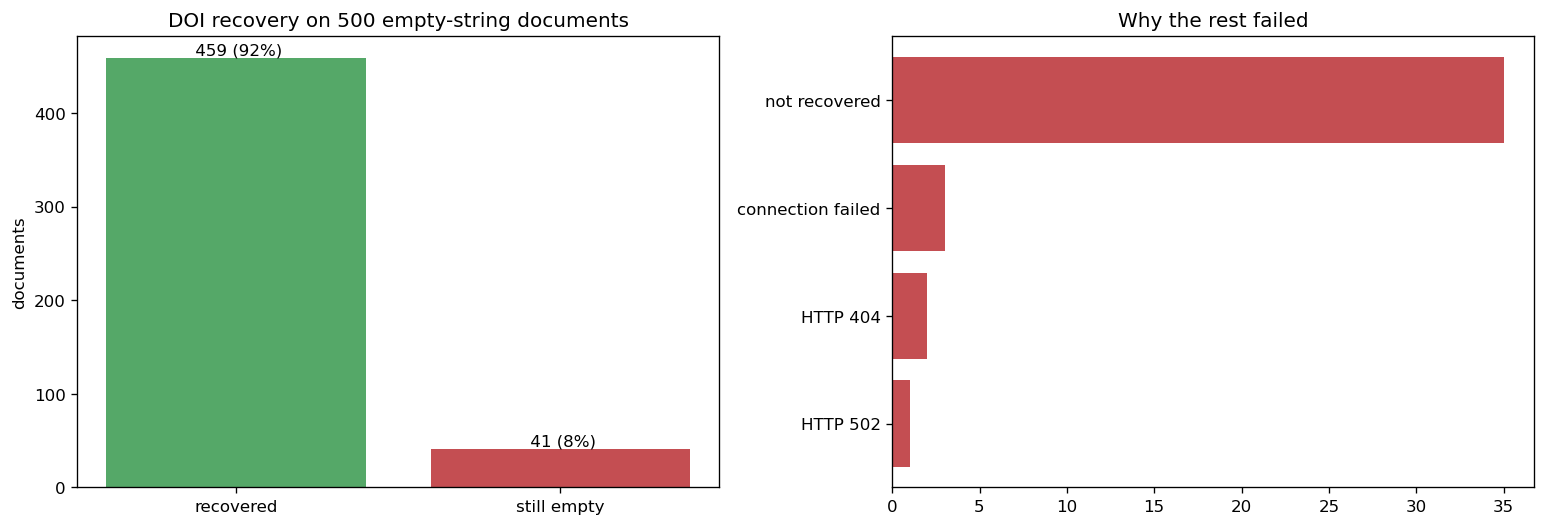

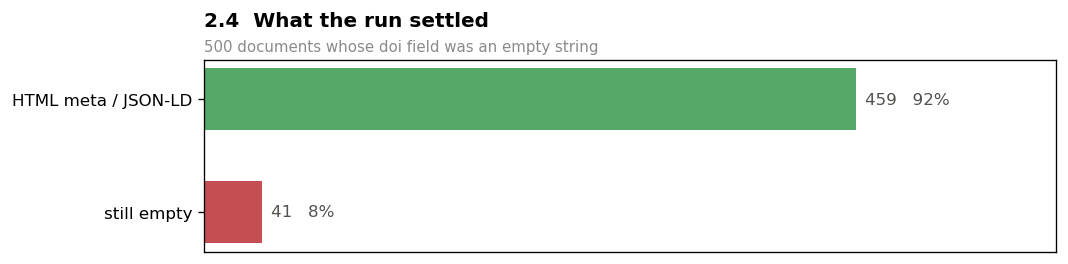


### What this path can and cannot do

**Feasible — do these.** Parse `identifier` / `main_entity_of_page` / `url` for
`doi.org/10.` or `10.xxxx/…` (no HTTP). Call HAL and DOAJ JSON APIs from the
record id. Resolve the Handle to a landing URL, then read `dc:identifier` over
OAI-PMH. Read `citation_doi` / JSON-LD from HTML that returns 200. Validate
every candidate on **Crossref or DataCite** against `headline`. Scope a
production run by provider (OpenEdition, HAL, DOAJ). Stop writing `""` at ingest
so new records stay honestly empty.

**limitations**

The charts above are this run (`DOI_SAMPLE` documents, `search_after id asc`).
That slice is ISIDORE-heavy; it is not empty-string DOI as a class.

### **1. A Handle is not a DOI**

`identifier` values such as `1000` or `10402/era.10402`, and URLs on
`hdl.handle.net`, are Handle System ids. Route 0 finds nothing: the regex
needs `10.` plus a slash. The Handle API returns a landing URL, not `10.…`.

### **2. Crossref-only validation rejects DataCite DOIs**

The worked case above (`10402_era.10402`) already had `10.7939/R3XP6V886` in
the HTML. Crossref 404s; DataCite 200 and the title matches `headline`. Without
the DataCite check the candidate is stored as `rejected: not in Crossref`.

### **3. The first-id sample is ISIDORE, not HAL / DOAJ / OpenEdition**

Sorting on `id` asc hits short numeric ids first (handles). HAL and DOAJ APIs
rarely fire on this slice. A low recovery rate here does not mean 0 / 23 M.

### **4. Landing pages fail, or have no `citation_doi`**

`connection failed`, `HTTP 500`, and HTML with no meta / JSON-LD sit in
"still empty". Resolving the Handle to DSpace can still leave a page with no
DOI in the tags this path reads.

### **5. OAI does not fill that gap on every host**

`GetRecord` often returns no `dc:identifier` DOI for these Handles. OAI is
still the right route when the IR actually mints a DOI there.

### **6. Do not regex the HTML body, or invent a DOI from the title**

Reference lists put other `10.` strings on the page. Bibliographic Crossref
(title + first author, no DOI in hand) attaches the wrong paper (homonym,
preprint vs version of record).

### **7. Do not scrape the full empty-string population**

~23.2 M rows: same I/O wall as §2.3. DNB is often empty-string with no landing
page and never had a DOI. Empty-string and a missing field stay separate
counts. This notebook writes Excel, not Elasticsearch.


---
# 3. How long each solution takes

Measured on this run: `AUTHOR_SAMPLE` profiles for §1, `DOCUMENT_SAMPLE` documents for §2.3, `DOI_SAMPLE` documents for §2.4.

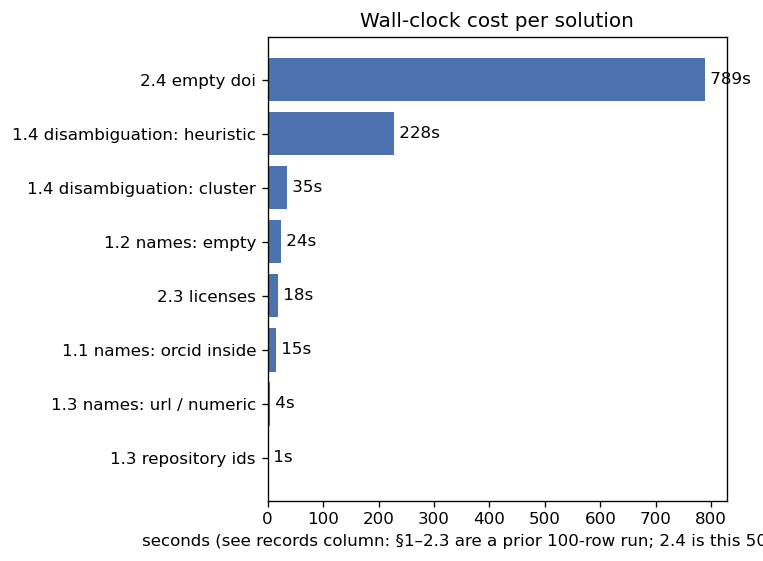


,solution,seconds,records,per record (s),"1,000 records"
0,1.1 names: orcid inside,15.2,100,0.152,2.5 min
1,1.2 names: empty,24.4,100,0.244,4.1 min
2,1.3 names: url / numeric,4.1,100,0.041,0.7 min
3,1.3 repository ids,0.8,100,0.008,0.1 min
4,1.4 disambiguation: cluster,34.6,100,0.346,5.8 min
5,1.4 disambiguation: heuristic,228.3,100,2.283,38.0 min
6,2.3 licenses,18.5,100,0.185,3.1 min
7,2.4 empty doi,789.2,500,1.578,26.3 min


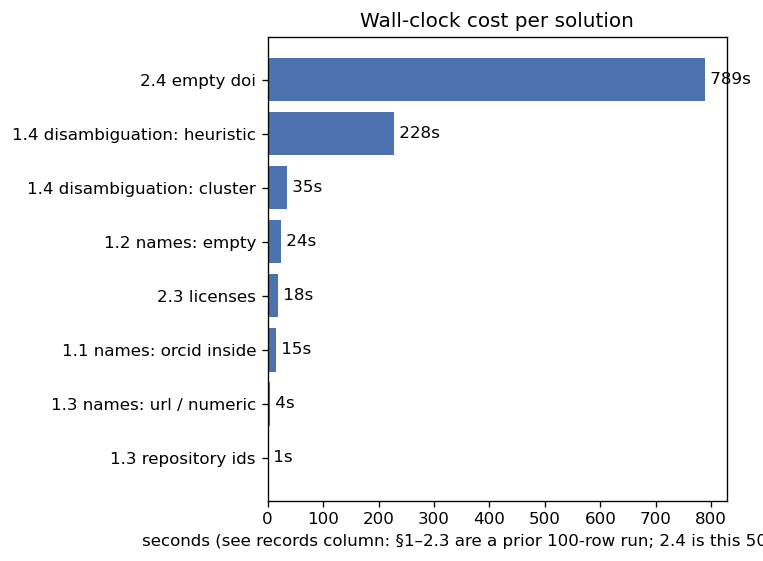

In [1]:
summary = pd.DataFrame({"solution": list(TIMINGS), "seconds": [round(v, 1) for v in TIMINGS.values()]})
summary["records"] = [
    DOI_SAMPLE if s.startswith("2.4") else DOCUMENT_SAMPLE if s.startswith("2.") else AUTHOR_SAMPLE
    for s in summary["solution"]
]
summary["per record (s)"] = (summary["seconds"] / summary["records"]).round(3)
summary["1,000 records"] = (summary["per record (s)"] * 1000 / 60).round(1).astype(str) + " min"
display(summary)

fig, ax = plt.subplots()
ordered = summary.sort_values("seconds")
ax.barh(ordered["solution"], ordered["seconds"], color=OK)
ax.set_xlabel(
    f"seconds for {AUTHOR_SAMPLE} author / {DOCUMENT_SAMPLE} license / {DOI_SAMPLE} DOI records")
ax.set_title("Wall-clock cost per solution")
ax.grid(axis="y", visible=False)
for i, v in enumerate(ordered["seconds"]):
    ax.text(v, i, f" {v:.0f}s", va="center")
plt.tight_layout(); plt.show()


### What dominates each timing

| solution | the slow part |
|---|---|
| 1.1 orcid inside | one `pub.orcid.org` request per profile (~0.16s each, incl. a deliberate 0.1s spacing) |
| 1.2 / 1.3 empty, junk | one batched documents query for the whole set, then the same per-profile API pass — except the bare numbers, which the batched query settles outright |
| 1.4 disambiguation | phase 1 is per-profile HTTP; phase 1b is one lookup per *distinct DOI*, cached and in parallel; phase 2 is CPU-only and compares every pair |
| 2.3 licenses | one HTTP GET per landing page, throttled per host, plus the Crossref/OpenAlex fallbacks |
| 2.4 empty doi | parse/API/OAI first (often no HTML); Crossref then DataCite only to *check* a candidate |

**Only phase 2 of clustering grows non-linearly.** It is O(n²) in the number of
records, so 10× the records is ~100× the clustering work. Everything else is
linear and I/O-bound, which also means it responds to more concurrency rather
than faster code.


In [1]:
per_record = TIMINGS["2.3 licenses"] / DOCUMENT_SAMPLE
population = count_elastic_documents("unresolved")

show_markdown(
    f"Projecting the full population from the timings above: at {per_record:.3f}s a document, the "
    f"{population:,} unresolved documents come to **about {population * per_record / 86400:,.0f} days** "
    "of wall clock. That job has to be scoped by provider or license value rather than run end to end; "
    "the author name-repair jobs, by contrast, are minutes to hours.")

if "2.4 empty doi" in TIMINGS:
    doi_per = TIMINGS["2.4 empty doi"] / DOI_SAMPLE
    doi_pop = count_elastic_doi_documents("empty_string")
    show_markdown(
        f"Empty-string DOI at {doi_per:.3f}s a document: the {doi_pop:,} rows come to "
        f"**about {doi_pop * doi_per / 86400:,.0f} days** wall clock if scraped the long way. "
        "That is why §2.4 puts parse / provider API / OAI *before* HTML, and why a production "
        "run has to be scoped by provider (OpenEdition, HAL, DOAJ — not DNB, not a BASE dump).")


Projecting the full population from the timings above: at 0.185s a document, the 38,382,096 unresolved documents come to **about 82 days** of wall clock. That job has to be scoped by provider or license value rather than run end to end; the author name-repair jobs, by contrast, are minutes to hours.

Empty-string DOI at 1.578s a document: the 23,203,138 rows come to **about 424 days** wall clock if scraped the long way. That is why §2.4 puts parse / provider API / OAI *before* HTML, and why a production run has to be scoped by provider (OpenEdition, HAL, DOAJ — not DNB, not a BASE dump).